In [1]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [3]:
%pip install pandas numpy requests beautifulsoup4 selenium webdriver-manager openpyxl matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

options = Options()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(options=options)

print("Selenium is working!")

Selenium is working!


In [5]:
url = "https://www.nykaa.com/"

driver.get(url)

print("Website Title:", driver.title)
print("Current URL:", driver.current_url)

Website Title: Buy Cosmetics Products & Beauty Products Online in India at Best Price | Nykaa
Current URL: https://www.nykaa.com/


In [6]:
from selenium.webdriver.common.by import By

links = driver.find_elements(By.TAG_NAME, "a")

print("Total links found:", len(links))

for link in links[:50]:
    text = link.text.strip()
    href = link.get_attribute("href")
    
    if text:
        print(text, "->", href)

Total links found: 5063
Shaadi glow starts with the right beauty picks -> https://www.nykaa.com/sp/offers-native/offers
mobile icon
Get App -> https://www.nykaa.com/explore/lp
address icon
Store & Events -> https://www.nykaa.com/stores-n-events-desktop
giftcard icon
Gift Card -> https://www.nykaa.com/giftcard.html?root=hdr_giftcards
help icon
Help -> https://www.nykaa.com/gateway-api/omsApis/helpCenter?domain=NYKAA
Nykaa Logo -> https://www.nykaa.com/?root=logo
Categories -> https://www.nykaa.com/
Brands -> https://www.nykaa.com/


In [7]:
health_url = "https://www.nykaa.com/wellness/c/671"

driver.get(health_url)

print("Page title:", driver.title)
print("Current URL:", driver.current_url)

Page title: Buy Health & Wellness Products Online In India At Great Price Offers
Current URL: https://www.nykaa.com/wellness/c/671


In [8]:
from selenium.webdriver.common.by import By

products = driver.find_elements(By.CSS_SELECTOR, "a[href*='/']")
    
print("Number of product-like links found:", len(products))

Number of product-like links found: 5202


In [9]:
product_links = driver.find_elements(
    By.CSS_SELECTOR,
    "a[href*='/p/']"
)

print("Product links found:", len(product_links))

for link in product_links[:20]:
    print(link.text.strip(), "->", link.get_attribute("href"))

Product links found: 36
Beautywise Skin Brilliance Glutathione Dual Action for Skin ...
₹2899
₹2261
22% Off
Regular price ₹2899. Discounted price ₹2261. 22% Off.
( 1672 )
2 Sizes -> https://www.nykaa.com/beautywise-skin-brilliance-capsules/p/15963105?productId=15963105&pps=1
Be Bodywise Biotin Hair Gummies - Zinc, Fibre, Multivitamin ...
₹999
₹849
15% Off
Regular price ₹999. Discounted price ₹849. 15% Off.
( 12264 )
2 Sizes -> https://www.nykaa.com/be-bodywise-biotin-hair-gummies-zinc-fibre-multivitamin-for-stronger-hair-nails-no-added-sugar/p/16576533?productId=16576533&pps=2
Be Bodywise Biotin Hair Gummies - Zinc, Fibre, Multivitamin ...
Price ₹549.
₹549
( 12264 ) -> https://www.nykaa.com/be-bodywise-biotin-hair-gummies-zinc-fibre-multivitamin-for-stronger-hair-nails-no-added-sugar/p/16576533?productId=16576533&skuId=16576532&pps=3
HealthKart Hk Vitals Skin Radiance Collagen Supplement With ...
₹975
₹909
7% Off
Regular price ₹975. Discounted price ₹909. 7% Off.
( 10121 )
3 Sizes -> h

In [10]:
first_product = product_links[0]

print("Product URL:")
print(first_product.get_attribute("href"))

print("\nProduct text:")
print(first_product.text)

Product URL:
https://www.nykaa.com/beautywise-skin-brilliance-capsules/p/15963105?productId=15963105&pps=1

Product text:
Beautywise Skin Brilliance Glutathione Dual Action for Skin ...
₹2899
₹2261
22% Off
Regular price ₹2899. Discounted price ₹2261. 22% Off.
( 1672 )
2 Sizes


In [11]:
import pandas as pd

healthcare_data = []

for link in product_links:
    product_name = link.text.strip()
    product_url = link.get_attribute("href")

    if product_name and product_url:
        healthcare_data.append({
            "Product_Name": product_name,
            "Product_URL": product_url
        })

healthcare_df = pd.DataFrame(healthcare_data)

print("Total products collected:", len(healthcare_df))

healthcare_df.head(10)

Total products collected: 35


,Product_Name,Product_URL
0,Beautywise Skin Brilliance Glutathione Dual Ac...,https://www.nykaa.com/beautywise-skin-brillian...
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",https://www.nykaa.com/be-bodywise-biotin-hair-...
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",https://www.nykaa.com/be-bodywise-biotin-hair-...
3,HealthKart Hk Vitals Skin Radiance Collagen Su...,https://www.nykaa.com/healthkart-hk-vitals-ski...
4,hoop Magnesium Sleep Body Lotion Topical Magne...,https://www.nykaa.com/hoop-magnesium-sleep-bod...
5,HealthKart Hk Vitals Multivitamin + Fish Oil\n...,https://www.nykaa.com/healthkart-hk-vitals-mul...
6,Plix Apple Cider Vinegar Effervescent Tablets ...,https://www.nykaa.com/plix-world-s-first-acv-j...
7,Be Bodywise Collagen Builder Gummies Vitamins ...,https://www.nykaa.com/be-bodywise-collagen-ski...
8,Beautywise Skin Brilliance Glutathione Dual Ac...,https://www.nykaa.com/beautywise-skin-brillian...
9,Kapiva Wild Amla Juice (Cold Pressed)Suitable ...,https://www.nykaa.com/kapiva-ayurveda-amla-jui...


In [12]:
# Open the first product page
first_url = healthcare_df.loc[0, "Product_URL"]

driver.get(first_url)

# Wait for the page to load
import time
time.sleep(5)

print("Product page opened!")
print("URL:", driver.current_url)
print("Title:", driver.title)

Product page opened!
URL: https://www.nykaa.com/beautywise-skin-brilliance-capsules/p/15963105?productId=15963105&pps=1&skuId=10805011
Title: Buy Beautywise Skin Brilliance Glutathione Dual Action for Skin Brightening and Glow Capsules Online


In [13]:
from bs4 import BeautifulSoup

# Get the current product page HTML
html = driver.page_source

# Parse the HTML
soup = BeautifulSoup(html, "html.parser")

# Get visible page text
page_text = soup.get_text(" ", strip=True)

print(page_text[:3000])

Buy Beautywise Skin Brilliance Glutathione Dual Action for Skin Brightening and Glow Capsules Online Shaadi glow starts with the right beauty picks mobile icon Get App address icon Store & Events giftcard icon Gift Card help icon Help Nykaa Logo categories brands topbrands Maybelline New York Lakme Nykaa Cosmetics M.A.C The Face Shop L'Oreal Paris Nykaa Naturals Biotique Huda Beauty Kama Ayurveda Innisfree The Body Shop # &Done &honey 18.21 Man Made 2PEACE 360 Block 3TENX 4711 5 Elements by Radhika Gupta 513 52 Sundaze 7-10 90 Feet By Dharavi Market 925 SILLER 999Store A A Big Indian Story A Clutch Story Aadita AANCHAL SAYAL AANURA AAPNO RAJASTHAN Aaranyaa Aarke Ritu Kumar AARSEE OFFICIAL Aaruvi Ruchi Verma Aarvi Decor Aastey Aatmana Abdesigns Abees ABELARDO DE MODA Abelino ABHUSHANAM ABKASA About Face ABSO Essentials Absorbia Acad Home Accessher Accessorize London Ace Blend ACE THE SPACE ACKROSS Acnestar Addery Addons Adhyay adidas Adidas Fragrances adidas Originals Adira ADITI WASAN 

In [14]:
import re

# Find all text containing ₹ (price)
prices = soup.find_all(string=re.compile("₹"))

print("Price-related text found:")
for text in prices[:30]:
    text = text.strip()
    if text:
        print(text)

Price-related text found:
₹2899
₹2261
Regular price ₹2899. Discounted price ₹2261. 22% Off.
₹2899
₹2261
Regular price ₹2899. Discounted price ₹2261. 22% Off.
window.__PRELOADED_STATE__ = {"appReducer":{"pageType":null,"statusCode":200,"storeId":"","configFlagsFetched":true,"run":100,"client":{"device":"WEB"},"breadCrumb":[{"value":"/","key":"Home"},{"key":"Health & Wellness","value":"wellness/c/671"},{"key":"Beauty Boosters","value":"wellness/beauty-boosters/c/18546"},{"key":"Glutathione","value":"wellness/beauty-boosters/glutathione/c/18550"}],"isSliderOpen":false,"showBreadcrumb":false,"pathname":"/beautywise-skin-brilliance-capsules/p/15963105","region":{"regionHeader":"TG","regionHeaderCountry":"IN"}},"auth":{"fetching":false,"dataFetched":false,"isFetchingError":false,"fetchedOverNetwork":false,"user":{"cartItemsCount":0,"email":"","firstName":"","formKey":"","groupId":"","id":"","isLoyal":false,"isPro":false,"lastName":"","rewardPoints":0,"userName":"","wishlist":[],"priveBand":"

In [15]:
import re

# Extract product details from the page source
def extract_field(pattern, html):
    match = re.search(pattern, html)
    if match:
        return match.group(1)
    return None

product_name = extract_field(r'"name":"([^"]+)"', html)
brand = extract_field(r'"brandName":"([^"]+)"', html)
offer_price = extract_field(r'"offerPrice":(\d+)', html)
rating = extract_field(r'"rating":"([^"]+)"', html)
pack_size = extract_field(r'"packSize":"([^"]+)"', html)
sku = extract_field(r'"sku":"([^"]+)"', html)

print("Product Name :", product_name)
print("Brand        :", brand)
print("Offer Price  :", offer_price)
print("Rating       :", rating)
print("Pack Size    :", pack_size)
print("SKU          :", sku)

Product Name : Beautywise Skin Brilliance Glutathione Dual Action for Skin Brightening and Glow Capsules
Brand        : Beautywise
Offer Price  : 2261
Rating       : None
Pack Size    : 60 Capsules
SKU          : BEAAJ00000005


In [16]:
# Extract MRP
mrp = extract_field(r'"mrp":(\d+)', html)

# Extract discount
discount = extract_field(r'"discount":(\d+)', html)

# Extract rating count
rating_count = extract_field(r'"ratingCount":(\d+)', html)

# Extract review count
review_count = extract_field(r'"reviewCount":(\d+)', html)

# Extract stock status
in_stock = extract_field(r'"inStock":(true|false)', html)

print("MRP           :", mrp)
print("Discount      :", discount)
print("Rating Count  :", rating_count)
print("Review Count  :", review_count)
print("In Stock      :", in_stock)

MRP           : 2899
Discount      : 22
Rating Count  : 1672
Review Count  : None
In Stock      : true


In [17]:
# Check the actual field names available in Nykaa's product data

fields_to_check = [
    "mrp",
    "discount",
    "ratingCount",
    "reviewCount",
    "inStock",
    "offerPrice",
    "brandName",
    "packSize"
]

for field in fields_to_check:
    print("\n" + "=" * 40)
    print("SEARCHING:", field)
    
    position = html.find('"' + field + '"')
    
    if position != -1:
        print(html[position:position + 250])
    else:
        print("Field not found")


SEARCHING: mrp
"mrp":2899,"name":"Beautywise Skin Brilliance Glutathione Dual Action for Skin Brightening and Glow Capsules","offerPrice":2261,"sku":"BEAAJ00000005","brandName":"Beautywise","packSize":"60 Capsules","rating":4.5,"productType":"configurable","slug":"

SEARCHING: discount
"discount":22,"reviewCount":"334","ratingCount":1672,"variantType":"weight_configure","tags":[],"variantCount":2,"selectedVariantName":"30 capsules","cohortSaleTemplate":null,"childId":"10805011"},"hasOffer":"yes","analyticsSdkData":{"pdpProductId":"

SEARCHING: ratingCount
"ratingCount":1672,"variantType":"weight_configure","tags":[],"variantCount":2,"selectedVariantName":"30 capsules","cohortSaleTemplate":null,"childId":"10805011"},"hasOffer":"yes","analyticsSdkData":{"pdpProductId":"15963105","pdpProductName":"Beauty

SEARCHING: reviewCount
"reviewCount":"334","ratingCount":1672,"variantType":"weight_configure","tags":[],"variantCount":2,"selectedVariantName":"30 capsules","cohortSaleTemplate":null,"

In [18]:
import re
import pandas as pd

def get_value(pattern, text):
    match = re.search(pattern, text)
    return match.group(1) if match else None

product_name = get_value(r'"name":"([^"]+)"', html)
brand = get_value(r'"brandName":"([^"]+)"', html)

mrp = get_value(r'"mrp":(\d+)', html)
selling_price = get_value(r'"offerPrice":(\d+)', html)

rating = get_value(r'"rating":([\d.]+)', html)
rating_count = get_value(r'"ratingCount":(\d+)', html)
review_count = get_value(r'"reviewCount":(\d+)', html)

pack_size = get_value(r'"packSize":"([^"]+)"', html)
stock = get_value(r'"inStock":(true|false)', html)

if mrp and selling_price:
    discount_percent = round(
        (int(mrp) - int(selling_price)) / int(mrp) * 100
    )
else:
    discount_percent = None

product_record = {
    "Product_Name": product_name,
    "Brand": brand,
    "Category": "Healthcare",
    "MRP": mrp,
    "Selling_Price": selling_price,
    "Discount_Percent": discount_percent,
    "Rating": rating,
    "Rating_Count": rating_count,
    "Review_Count": review_count,
    "Pack_Size": pack_size,
    "In_Stock": stock,
    "Product_URL": driver.current_url
}

test_df = pd.DataFrame([product_record])

test_df

,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL
0,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,2899,2261,22,4.5,1672,None,60 Capsules,true,https://www.nykaa.com/beautywise-skin-brillian...


In [19]:
import time
import re
import pandas as pd
from datetime import date

def extract(pattern, html):
    match = re.search(pattern, html)
    return match.group(1) if match else None

# Remove duplicate product URLs
health_urls = healthcare_df["Product_URL"].dropna().drop_duplicates().tolist()

print("Unique Healthcare products to scrape:", len(health_urls))

healthcare_results = []

for i, url in enumerate(health_urls, start=1):

    try:
        print(f"Scraping {i}/{len(health_urls)}")

        driver.get(url)
        time.sleep(3)

        page = driver.page_source

        product_name = extract(r'"name":"([^"]+)"', page)
        brand = extract(r'"brandName":"([^"]+)"', page)

        mrp = extract(r'"mrp":(\d+(?:\.\d+)?)', page)
        selling_price = extract(r'"offerPrice":(\d+(?:\.\d+)?)', page)

        rating = extract(r'"rating":("?)([\d.]+)\1', page)
        rating_count = extract(r'"ratingCount":(\d+)', page)
        review_count = extract(r'"reviewCount":(\d+)', page)

        pack_size = extract(r'"packSize":"([^"]+)"', page)
        stock = extract(r'"inStock":(true|false)', page)

        # Calculate discount
        if mrp and selling_price:
            discount = round(
                (float(mrp) - float(selling_price))
                / float(mrp) * 100
            )
        else:
            discount = None

        healthcare_results.append({
            "Product_Name": product_name,
            "Brand": brand,
            "Category": "Healthcare",
            "MRP": mrp,
            "Selling_Price": selling_price,
            "Discount_Percent": discount,
            "Rating": rating,
            "Rating_Count": rating_count,
            "Review_Count": review_count,
            "Pack_Size": pack_size,
            "In_Stock": stock,
            "Product_URL": url,
            "Scraped_Date": date.today()
        })

    except Exception as e:
        print("Error:", e)

healthcare_full_df = pd.DataFrame(healthcare_results)

print("\nScraping completed!")
print("Total products:", len(healthcare_full_df))

healthcare_full_df.head()

Unique Healthcare products to scrape: 31
Scraping 1/31
Scraping 2/31
Scraping 3/31
Scraping 4/31
Scraping 5/31
Scraping 6/31
Scraping 7/31
Scraping 8/31
Scraping 9/31
Scraping 10/31
Scraping 11/31
Scraping 12/31
Scraping 13/31
Scraping 14/31
Scraping 15/31
Scraping 16/31
Scraping 17/31
Scraping 18/31
Scraping 19/31
Scraping 20/31
Scraping 21/31
Scraping 22/31
Scraping 23/31
Scraping 24/31
Scraping 25/31
Scraping 26/31
Scraping 27/31
Scraping 28/31
Scraping 29/31
Scraping 30/31
Scraping 31/31

Scraping completed!
Total products: 31


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date
0,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,2899,2261,22,,1672,None,60 Capsules,true,https://www.nykaa.com/beautywise-skin-brillian...,2026-09-14
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,999,849,15,,12264,None,60 gummies,true,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,549,549,0,,12264,None,30 gummies,true,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14
3,HealthKart HK Vitals Skin Radiance Collagen Su...,HealthKart,Healthcare,975,909,7,,10121,None,200g,true,https://www.nykaa.com/healthkart-hk-vitals-ski...,2026-09-14
4,hoop Magnesium Sleep Body Lotion Topical Magne...,hoop,Healthcare,680,520,24,,359,None,250ml,true,https://www.nykaa.com/hoop-magnesium-sleep-bod...,2026-09-14


In [20]:
# Fix Review_Count by reading the product pages again
import re
import time

def extract_review_count(html):
    match = re.search(r'"reviewCount"\s*:\s*(\d+)', html)
    return int(match.group(1)) if match else None

for i, url in enumerate(healthcare_full_df["Product_URL"], start=1):
    print(f"Checking reviews {i}/{len(healthcare_full_df)}")
    
    driver.get(url)
    time.sleep(2)
    
    page = driver.page_source
    
    healthcare_full_df.loc[i-1, "Review_Count"] = extract_review_count(page)

print("\nReview counts updated!")

healthcare_full_df[[
    "Product_Name",
    "Rating_Count",
    "Review_Count"
]].head(10)

Checking reviews 1/31
Checking reviews 2/31
Checking reviews 3/31
Checking reviews 4/31
Checking reviews 5/31
Checking reviews 6/31
Checking reviews 7/31
Checking reviews 8/31
Checking reviews 9/31
Checking reviews 10/31
Checking reviews 11/31
Checking reviews 12/31
Checking reviews 13/31
Checking reviews 14/31
Checking reviews 15/31
Checking reviews 16/31
Checking reviews 17/31
Checking reviews 18/31
Checking reviews 19/31
Checking reviews 20/31
Checking reviews 21/31
Checking reviews 22/31
Checking reviews 23/31
Checking reviews 24/31
Checking reviews 25/31
Checking reviews 26/31
Checking reviews 27/31
Checking reviews 28/31
Checking reviews 29/31
Checking reviews 30/31
Checking reviews 31/31

Review counts updated!


,Product_Name,Rating_Count,Review_Count
0,Beautywise Skin Brilliance Glutathione Dual Ac...,1672,None
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",12264,None
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",12264,None
3,HealthKart HK Vitals Skin Radiance Collagen Su...,10121,None
4,hoop Magnesium Sleep Body Lotion Topical Magne...,359,None
5,HealthKart Hk Vitals Multivitamin + Fish Oil,83,None
6,Plix Apple Cider Vinegar Effervescent Tablets ...,735,None
7,Be Bodywise Collagen Builder Gummies Vitamins ...,1376,None
8,Beautywise Skin Brilliance Glutathione Dual Ac...,1672,None
9,Kapiva Wild Amla Juice (Cold Pressed)Suitable ...,1206,None


In [21]:
# Find the exact reviewCount text in the current product page

position = page.find('"reviewCount"')

print("Position:", position)

if position != -1:
    print("\nData around reviewCount:")
    print(page[position:position + 200])
else:
    print("reviewCount was not found on this page.")

Position: 1095022

Data around reviewCount:
"reviewCount":"80","ratingCount":412,"tags":[],"variantCount":0,"selectedVariantName":"","cohortSaleTemplate":null},"hasOffer":"yes","analyticsSdkData":{"pdpProductId":"21495072","pdpProductName":"Mid


In [22]:
import re

def get_review_count(html):
    match = re.search(r'"reviewCount"\s*:\s*(\d+)', html)
    if match:
        return int(match.group(1))
    return None

# Test on the current page
review_test = get_review_count(page)

print("Review count found:", review_test)

Review count found: None


In [23]:
# Get the latest page source
current_html = driver.page_source

# Search for anything containing "review"
import re

matches = re.findall(r'.{0,80}review.{0,120}', current_html, re.IGNORECASE)

print("Number of review-related matches:", len(matches))

for match in matches[:20]:
    print("\n", match)

Number of review-related matches: 52

 ating(s)<span>4.2<!-- --> out of 5 stars</span></div><div aria-label="Rating: 5 Reviews: (260)" class="css-kxc9rx"><label aria-hidden="true" class="css-1m3er3d">5<svg xmlns="http://www.w3.org/2000/svg" widt

 ia-hidden="true" class="css-11lfsnj">260</span></div><div aria-label="Rating: 4 Reviews: (67)" class="css-kxc9rx"><label aria-hidden="true" class="css-1m3er3d">4<svg xmlns="http://www.w3.org/2000/svg" width

 ria-hidden="true" class="css-11lfsnj">67</span></div><div aria-label="Rating: 3 Reviews: (39)" class="css-kxc9rx"><label aria-hidden="true" class="css-1m3er3d">3<svg xmlns="http://www.w3.org/2000/svg" width

 ria-hidden="true" class="css-11lfsnj">39</span></div><div aria-label="Rating: 2 Reviews: (7)" class="css-kxc9rx"><label aria-hidden="true" class="css-1m3er3d">2<svg xmlns="http://www.w3.org/2000/svg" width=

 aria-hidden="true" class="css-11lfsnj">7</span></div><div aria-label="Rating: 1 Reviews: (39)" class="css-kxc9rx"><label aria

In [24]:
import re
import time

def get_review_count(html):
    match = re.search(r'"reviewCount"\s*:\s*"(\d+)"', html)
    return int(match.group(1)) if match else None

for i, url in enumerate(healthcare_full_df["Product_URL"], start=1):
    print(f"Updating reviews {i}/{len(healthcare_full_df)}")

    driver.get(url)
    time.sleep(2)

    current_html = driver.page_source

    healthcare_full_df.loc[i-1, "Review_Count"] = get_review_count(current_html)

print("\n✅ Review counts updated!")

healthcare_full_df[
    ["Product_Name", "Rating_Count", "Review_Count"]
].head(10)

Updating reviews 1/31
Updating reviews 2/31
Updating reviews 3/31
Updating reviews 4/31
Updating reviews 5/31
Updating reviews 6/31
Updating reviews 7/31
Updating reviews 8/31
Updating reviews 9/31
Updating reviews 10/31
Updating reviews 11/31
Updating reviews 12/31
Updating reviews 13/31
Updating reviews 14/31
Updating reviews 15/31
Updating reviews 16/31
Updating reviews 17/31
Updating reviews 18/31
Updating reviews 19/31
Updating reviews 20/31
Updating reviews 21/31
Updating reviews 22/31
Updating reviews 23/31
Updating reviews 24/31
Updating reviews 25/31
Updating reviews 26/31
Updating reviews 27/31
Updating reviews 28/31
Updating reviews 29/31
Updating reviews 30/31
Updating reviews 31/31

✅ Review counts updated!


,Product_Name,Rating_Count,Review_Count
0,Beautywise Skin Brilliance Glutathione Dual Ac...,1672,334
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",12264,529
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",12264,529
3,HealthKart HK Vitals Skin Radiance Collagen Su...,10121,332
4,hoop Magnesium Sleep Body Lotion Topical Magne...,359,52
5,HealthKart Hk Vitals Multivitamin + Fish Oil,83,5
6,Plix Apple Cider Vinegar Effervescent Tablets ...,735,35
7,Be Bodywise Collagen Builder Gummies Vitamins ...,1376,114
8,Beautywise Skin Brilliance Glutathione Dual Ac...,1672,334
9,Kapiva Wild Amla Juice (Cold Pressed)Suitable ...,1206,137


In [25]:
# Create a copy for cleaning
healthcare_clean = healthcare_full_df.copy()

# 1. Remove duplicate products using Product URL
healthcare_clean = healthcare_clean.drop_duplicates(
    subset="Product_URL"
).reset_index(drop=True)

# 2. Convert numeric columns to numbers
numeric_columns = [
    "MRP",
    "Selling_Price",
    "Discount_Percent",
    "Rating",
    "Rating_Count",
    "Review_Count"
]

for column in numeric_columns:
    healthcare_clean[column] = pd.to_numeric(
        healthcare_clean[column],
        errors="coerce"
    )

# 3. Convert stock status to readable values
healthcare_clean["In_Stock"] = healthcare_clean["In_Stock"].map({
    True: "In Stock",
    False: "Out of Stock",
    "true": "In Stock",
    "false": "Out of Stock"
})

# 4. Remove rows where product name or URL is missing
healthcare_clean = healthcare_clean.dropna(
    subset=["Product_Name", "Product_URL"]
).reset_index(drop=True)

# 5. Check the cleaned dataset
print("Total products after cleaning:", len(healthcare_clean))
print("\nMissing values:")
print(healthcare_clean.isnull().sum())

healthcare_clean.head(10)

Total products after cleaning: 31

Missing values:
Product_Name         0
Brand                0
Category             0
MRP                  0
Selling_Price        0
Discount_Percent     0
Rating              31
Rating_Count         0
Review_Count         0
Pack_Size            0
In_Stock             0
Product_URL          0
Scraped_Date         0
dtype: int64


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date
0,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,2899,2261,22,NaN,1672,334,60 Capsules,In Stock,https://www.nykaa.com/beautywise-skin-brillian...,2026-09-14
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,999,849,15,NaN,12264,529,60 gummies,In Stock,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,549,549,0,NaN,12264,529,30 gummies,In Stock,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14
3,HealthKart HK Vitals Skin Radiance Collagen Su...,HealthKart,Healthcare,975,909,7,NaN,10121,332,200g,In Stock,https://www.nykaa.com/healthkart-hk-vitals-ski...,2026-09-14
4,hoop Magnesium Sleep Body Lotion Topical Magne...,hoop,Healthcare,680,520,24,NaN,359,52,250ml,In Stock,https://www.nykaa.com/hoop-magnesium-sleep-bod...,2026-09-14
5,HealthKart Hk Vitals Multivitamin + Fish Oil,HealthKart,Healthcare,669,489,27,NaN,83,5,60tablets,In Stock,https://www.nykaa.com/healthkart-hk-vitals-mul...,2026-09-14
6,Plix Apple Cider Vinegar Effervescent Tablets ...,Plix,Healthcare,1245,1071,14,NaN,735,35,60 Tablets,In Stock,https://www.nykaa.com/plix-world-s-first-acv-j...,2026-09-14
7,Be Bodywise Collagen Builder Gummies Vitamins ...,Be Bodywise,Healthcare,999,449,55,NaN,1376,114,60 gummies,In Stock,https://www.nykaa.com/be-bodywise-collagen-ski...,2026-09-14
8,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,1699,1359,20,NaN,1672,334,30 capsules,In Stock,https://www.nykaa.com/beautywise-skin-brillian...,2026-09-14
9,Kapiva Wild Amla Juice (Cold Pressed)Suitable ...,Kapiva Ayurveda,Healthcare,280,233,17,NaN,1206,137,1L,In Stock,https://www.nykaa.com/kapiva-ayurveda-amla-jui...,2026-09-14


In [26]:
# Check how Nykaa stores the rating

import re

rating_matches = re.findall(
    r'"rating"\s*:\s*(.{1,30})',
    current_html
)

print("Rating fields found:", len(rating_matches))

for match in rating_matches[:10]:
    print(match)

Rating fields found: 9
4.2,"productType":"simple","sl
4.2,"ratingCount":412,"returnM
5},{"title":"Glutathione ","de
5},{"title":"Exceed my expecta
5},{"title":"Visible Glow","de
5},{"title":"Best glutathione"
5}],"title":"Miduty Liposomal 
4.2,"productType":"simple","sl
4.2,"productType":"simple","sl


In [27]:
import re
import time

def get_rating(html):
    match = re.search(r'"rating"\s*:\s*"?([\d.]+)"?', html)
    return float(match.group(1)) if match else None

for i, url in enumerate(healthcare_clean["Product_URL"], start=1):
    print(f"Updating rating {i}/{len(healthcare_clean)}")

    driver.get(url)
    time.sleep(2)

    current_html = driver.page_source

    healthcare_clean.loc[i-1, "Rating"] = get_rating(current_html)

print("\n✅ Ratings updated!")

healthcare_clean[
    ["Product_Name", "Rating", "Rating_Count", "Review_Count"]
].head(10)

Updating rating 1/31
Updating rating 2/31
Updating rating 3/31
Updating rating 4/31
Updating rating 5/31
Updating rating 6/31
Updating rating 7/31
Updating rating 8/31
Updating rating 9/31
Updating rating 10/31
Updating rating 11/31
Updating rating 12/31
Updating rating 13/31
Updating rating 14/31
Updating rating 15/31
Updating rating 16/31
Updating rating 17/31
Updating rating 18/31
Updating rating 19/31
Updating rating 20/31
Updating rating 21/31
Updating rating 22/31
Updating rating 23/31
Updating rating 24/31
Updating rating 25/31
Updating rating 26/31
Updating rating 27/31
Updating rating 28/31
Updating rating 29/31
Updating rating 30/31
Updating rating 31/31

✅ Ratings updated!


,Product_Name,Rating,Rating_Count,Review_Count
0,Beautywise Skin Brilliance Glutathione Dual Ac...,4.5,1672,334
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",4.3,12264,529
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",4.3,12264,529
3,HealthKart HK Vitals Skin Radiance Collagen Su...,4.2,10121,332
4,hoop Magnesium Sleep Body Lotion Topical Magne...,4.4,359,52
5,HealthKart Hk Vitals Multivitamin + Fish Oil,4.0,83,5
6,Plix Apple Cider Vinegar Effervescent Tablets ...,4.3,735,35
7,Be Bodywise Collagen Builder Gummies Vitamins ...,4.2,1376,114
8,Beautywise Skin Brilliance Glutathione Dual Ac...,4.5,1672,334
9,Kapiva Wild Amla Juice (Cold Pressed)Suitable ...,4.4,1206,137


In [28]:
# Final Healthcare dataset preparation

# Make a final copy
healthcare_final = healthcare_clean.copy()

# Make sure numeric columns have the correct data type
numeric_columns = [
    "MRP",
    "Selling_Price",
    "Discount_Percent",
    "Rating",
    "Rating_Count",
    "Review_Count"
]

for col in numeric_columns:
    healthcare_final[col] = pd.to_numeric(
        healthcare_final[col],
        errors="coerce"
    )

# Add Price Range for future analysis
def price_range(price):
    if price < 500:
        return "Below ₹500"
    elif price < 1000:
        return "₹500–₹999"
    elif price < 2000:
        return "₹1,000–₹1,999"
    else:
        return "₹2,000+"

healthcare_final["Price_Range"] = healthcare_final["Selling_Price"].apply(
    price_range
)

# Save CSV
healthcare_final.to_csv(
    "healthcare_products_cleaned.csv",
    index=False
)

# Save Excel
healthcare_final.to_excel(
    "healthcare_products_cleaned.xlsx",
    index=False
)

print("✅ Healthcare CSV saved successfully!")
print("✅ Healthcare Excel saved successfully!")
print("Total products:", len(healthcare_final))

healthcare_final.head(10)

✅ Healthcare CSV saved successfully!
✅ Healthcare Excel saved successfully!
Total products: 31


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date,Price_Range
0,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,2899,2261,22,4.5,1672,334,60 Capsules,In Stock,https://www.nykaa.com/beautywise-skin-brillian...,2026-09-14,"₹2,000+"
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,999,849,15,4.3,12264,529,60 gummies,In Stock,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14,₹500–₹999
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,549,549,0,4.3,12264,529,30 gummies,In Stock,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14,₹500–₹999
3,HealthKart HK Vitals Skin Radiance Collagen Su...,HealthKart,Healthcare,975,909,7,4.2,10121,332,200g,In Stock,https://www.nykaa.com/healthkart-hk-vitals-ski...,2026-09-14,₹500–₹999
4,hoop Magnesium Sleep Body Lotion Topical Magne...,hoop,Healthcare,680,520,24,4.4,359,52,250ml,In Stock,https://www.nykaa.com/hoop-magnesium-sleep-bod...,2026-09-14,₹500–₹999
5,HealthKart Hk Vitals Multivitamin + Fish Oil,HealthKart,Healthcare,669,489,27,4.0,83,5,60tablets,In Stock,https://www.nykaa.com/healthkart-hk-vitals-mul...,2026-09-14,Below ₹500
6,Plix Apple Cider Vinegar Effervescent Tablets ...,Plix,Healthcare,1245,1071,14,4.3,735,35,60 Tablets,In Stock,https://www.nykaa.com/plix-world-s-first-acv-j...,2026-09-14,"₹1,000–₹1,999"
7,Be Bodywise Collagen Builder Gummies Vitamins ...,Be Bodywise,Healthcare,999,449,55,4.2,1376,114,60 gummies,In Stock,https://www.nykaa.com/be-bodywise-collagen-ski...,2026-09-14,Below ₹500
8,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,1699,1359,20,4.5,1672,334,30 capsules,In Stock,https://www.nykaa.com/beautywise-skin-brillian...,2026-09-14,"₹1,000–₹1,999"
9,Kapiva Wild Amla Juice (Cold Pressed)Suitable ...,Kapiva Ayurveda,Healthcare,280,233,17,4.4,1206,137,1L,In Stock,https://www.nykaa.com/kapiva-ayurveda-amla-jui...,2026-09-14,Below ₹500


In [29]:
# Open Nykaa Beauty - Skincare category

beauty_url = "https://www.nykaa.com/skin/c/8377"

driver.get(beauty_url)

time.sleep(5)

print("Page title:", driver.title)
print("Current URL:", driver.current_url)

Page title: Skin Care - Buy Skin Care Products at Best Offers | Nykaa
Current URL: https://www.nykaa.com/skin/c/8377


In [30]:
# Find Beauty product links

beauty_links = driver.find_elements(
    By.CSS_SELECTOR,
    "a[href*='/p/']"
)

print("Total Beauty product links found:", len(beauty_links))

for link in beauty_links[:10]:
    print(
        link.text.strip(),
        "->",
        link.get_attribute("href")
    )

Total Beauty product links found: 36
The Derma Co 10% Niacinamide Face Serum For Acne Marks
₹849
₹594
30% Off
Regular price ₹849. Discounted price ₹594. 30% Off.
( 74771 ) -> https://www.nykaa.com/the-derma-co-10percent-niacinamide-face-serum-for-acne-marks/p/17108612?productId=17108612&skuId=22317341&pps=1
Dot & Key Vitamin C + E Super Bright Sunscreen, SPF 50+ PA++...
₹445
₹387
13% Off
Regular price ₹445. Discounted price ₹387. 13% Off.
( 170956 )
2 Sizes -> https://www.nykaa.com/dot-key-vitamin-c-e-face-sunscreen-with-spf-50-pa/p/13199519?productId=13199519&pps=2
Clinique Moisture Surge 100h Auto-replenishing Hydrator (Moi...
Price ₹3550.
₹3550
Enjoy Free Gift
( 82478 ) -> https://www.nykaa.com/clinique-moisture-surge-100h-auto-replenishing-hydrator/p/1129289?productId=1129289&skuId=1129287&pps=3
Anua Niacinamide 10 Txa 4 Serum, Brightening Korean Serum Fo...
₹2000
₹1900
5% Off
Regular price ₹2000. Discounted price ₹1900. 5% Off.
( 3071 ) -> https://www.nykaa.com/anua-niacinamide-10

In [31]:
import time
import re
import pandas as pd
from datetime import date

def extract_value(pattern, html):
    match = re.search(pattern, html)
    return match.group(1) if match else None

# Remove duplicate URLs
beauty_urls = list(dict.fromkeys([
    link.get_attribute("href")
    for link in beauty_links
    if link.get_attribute("href")
]))

print("Unique Beauty products to scrape:", len(beauty_urls))

beauty_results = []

for i, url in enumerate(beauty_urls, start=1):

    try:
        print(f"Scraping Beauty {i}/{len(beauty_urls)}")

        driver.get(url)
        time.sleep(2)

        page = driver.page_source

        product_name = extract_value(
            r'"name"\s*:\s*"([^"]+)"',
            page
        )

        brand = extract_value(
            r'"brandName"\s*:\s*"([^"]+)"',
            page
        )

        mrp = extract_value(
            r'"mrp"\s*:\s*(\d+(?:\.\d+)?)',
            page
        )

        selling_price = extract_value(
            r'"offerPrice"\s*:\s*(\d+(?:\.\d+)?)',
            page
        )

        rating = extract_value(
            r'"rating"\s*:\s*"?([\d.]+)"?',
            page
        )

        rating_count = extract_value(
            r'"ratingCount"\s*:\s*(\d+)',
            page
        )

        review_count = extract_value(
            r'"reviewCount"\s*:\s*"(\d+)"',
            page
        )

        pack_size = extract_value(
            r'"packSize"\s*:\s*"([^"]+)"',
            page
        )

        stock = extract_value(
            r'"inStock"\s*:\s*(true|false)',
            page
        )

        # Calculate discount
        if mrp and selling_price:
            discount = round(
                (float(mrp) - float(selling_price))
                / float(mrp) * 100
            )
        else:
            discount = None

        beauty_results.append({
            "Product_Name": product_name,
            "Brand": brand,
            "Category": "Beauty",
            "MRP": mrp,
            "Selling_Price": selling_price,
            "Discount_Percent": discount,
            "Rating": rating,
            "Rating_Count": rating_count,
            "Review_Count": review_count,
            "Pack_Size": pack_size,
            "In_Stock": stock,
            "Product_URL": url,
            "Scraped_Date": date.today()
        })

    except Exception as e:
        print("Error:", e)

beauty_df = pd.DataFrame(beauty_results)

print("\n✅ Beauty scraping completed!")
print("Total Beauty products:", len(beauty_df))

beauty_df.head(10)

Unique Beauty products to scrape: 32
Scraping Beauty 1/32
Scraping Beauty 2/32
Scraping Beauty 3/32
Scraping Beauty 4/32
Scraping Beauty 5/32
Scraping Beauty 6/32
Scraping Beauty 7/32
Scraping Beauty 8/32
Scraping Beauty 9/32
Scraping Beauty 10/32
Scraping Beauty 11/32
Scraping Beauty 12/32
Scraping Beauty 13/32
Scraping Beauty 14/32
Scraping Beauty 15/32
Scraping Beauty 16/32
Scraping Beauty 17/32
Scraping Beauty 18/32
Scraping Beauty 19/32
Scraping Beauty 20/32
Scraping Beauty 21/32
Scraping Beauty 22/32
Scraping Beauty 23/32
Scraping Beauty 24/32
Scraping Beauty 25/32
Scraping Beauty 26/32
Scraping Beauty 27/32
Scraping Beauty 28/32
Scraping Beauty 29/32
Scraping Beauty 30/32
Scraping Beauty 31/32
Scraping Beauty 32/32

✅ Beauty scraping completed!
Total Beauty products: 32


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date
0,The Derma Co 10% Niacinamide Face Serum For Ac...,The Derma Co,Beauty,849,594,30.0,4.3,74771,3178,50ml,true,https://www.nykaa.com/the-derma-co-10percent-n...,2026-09-14
1,Dot & Key Vitamin C + E Super Bright Sunscreen...,Dot & Key,Beauty,445,387,13.0,4.4,170956,8174,50g,true,https://www.nykaa.com/dot-key-vitamin-c-e-face...,2026-09-14
2,Clinique Moisture Surge 100h Auto-replenishing...,Clinique,Beauty,3550,3550,0.0,4.5,82478,5212,50ml,true,https://www.nykaa.com/clinique-moisture-surge-...,2026-09-14
3,"Anua Niacinamide 10 Txa 4 Serum, Brightening K...",Anua,Beauty,2000,1900,5.0,4.4,3071,504,30ml,true,https://www.nykaa.com/anua-niacinamide-10-txa-...,2026-09-14
4,Eucerin Anti Pigment Cleansing Gel 2% Exfoliat...,Eucerin,Beauty,1100,990,10.0,4.4,345,40,200ml,true,https://www.nykaa.com/eucerin-anti-pigment-cle...,2026-09-14
5,Dot & Key Ceramides & Hyaluronic Barrier Repai...,Dot & Key,Beauty,395,336,15.0,4.4,138423,8383,100g,true,https://www.nykaa.com/dot-key-ceramides-hyalur...,2026-09-14
6,"Cetaphil Gentle Skin Cleanser For Normal, Dry ...",Cetaphil,Beauty,459,418,9.0,4.5,431761,15611,118ml,true,https://www.nykaa.com/cetaphil-cleansing-lotio...,2026-09-14
7,"Foxtale De-Tan Face Mask For Tan Removal, Inst...",Foxtale,Beauty,545,469,14.0,4.2,22237,2149,75g,true,https://www.nykaa.com/foxtale-skin-radiance-ma...,2026-09-14
8,The Derma Co 10% Niacinamide Face Serum For Ac...,The Derma Co,Beauty,249,237,5.0,4.3,74771,3178,10ml,true,https://www.nykaa.com/the-derma-co-10percent-n...,2026-09-14
9,Aqualogica Glow+ Dewy Sunscreen Gel SPF 50+ PA...,Aqualogica,Beauty,499,429,14.0,4.4,200265,8322,50g,true,https://www.nykaa.com/aqualogica-glow-dewy-sun...,2026-09-14


In [32]:
# Create a copy for cleaning
beauty_clean = beauty_df.copy()

# Remove duplicate products based on Product URL
beauty_clean = beauty_clean.drop_duplicates(
    subset="Product_URL"
).reset_index(drop=True)

# Convert numeric columns
numeric_columns = [
    "MRP",
    "Selling_Price",
    "Discount_Percent",
    "Rating",
    "Rating_Count",
    "Review_Count"
]

for col in numeric_columns:
    beauty_clean[col] = pd.to_numeric(
        beauty_clean[col],
        errors="coerce"
    )

# Convert stock status
beauty_clean["In_Stock"] = beauty_clean["In_Stock"].map({
    True: "In Stock",
    False: "Out of Stock",
    "true": "In Stock",
    "false": "Out of Stock"
})

# Remove records without essential information
beauty_clean = beauty_clean.dropna(
    subset=["Product_Name", "Brand", "Product_URL"]
).reset_index(drop=True)

# Add price range
def beauty_price_range(price):
    if price < 500:
        return "Below ₹500"
    elif price < 1000:
        return "₹500–₹999"
    elif price < 2000:
        return "₹1,000–₹1,999"
    else:
        return "₹2,000+"

beauty_clean["Price_Range"] = beauty_clean["Selling_Price"].apply(
    beauty_price_range
)

print("Total Beauty products after cleaning:", len(beauty_clean))

print("\nMissing values:")
print(beauty_clean.isnull().sum())

beauty_clean.head(10)

Total Beauty products after cleaning: 31

Missing values:
Product_Name        0
Brand               0
Category            0
MRP                 0
Selling_Price       0
Discount_Percent    0
Rating              0
Rating_Count        0
Review_Count        0
Pack_Size           0
In_Stock            0
Product_URL         0
Scraped_Date        0
Price_Range         0
dtype: int64


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date,Price_Range
0,The Derma Co 10% Niacinamide Face Serum For Ac...,The Derma Co,Beauty,849.0,594.0,30.0,4.3,74771.0,3178.0,50ml,In Stock,https://www.nykaa.com/the-derma-co-10percent-n...,2026-09-14,₹500–₹999
1,Dot & Key Vitamin C + E Super Bright Sunscreen...,Dot & Key,Beauty,445.0,387.0,13.0,4.4,170956.0,8174.0,50g,In Stock,https://www.nykaa.com/dot-key-vitamin-c-e-face...,2026-09-14,Below ₹500
2,Clinique Moisture Surge 100h Auto-replenishing...,Clinique,Beauty,3550.0,3550.0,0.0,4.5,82478.0,5212.0,50ml,In Stock,https://www.nykaa.com/clinique-moisture-surge-...,2026-09-14,"₹2,000+"
3,"Anua Niacinamide 10 Txa 4 Serum, Brightening K...",Anua,Beauty,2000.0,1900.0,5.0,4.4,3071.0,504.0,30ml,In Stock,https://www.nykaa.com/anua-niacinamide-10-txa-...,2026-09-14,"₹1,000–₹1,999"
4,Eucerin Anti Pigment Cleansing Gel 2% Exfoliat...,Eucerin,Beauty,1100.0,990.0,10.0,4.4,345.0,40.0,200ml,In Stock,https://www.nykaa.com/eucerin-anti-pigment-cle...,2026-09-14,₹500–₹999
5,Dot & Key Ceramides & Hyaluronic Barrier Repai...,Dot & Key,Beauty,395.0,336.0,15.0,4.4,138423.0,8383.0,100g,In Stock,https://www.nykaa.com/dot-key-ceramides-hyalur...,2026-09-14,Below ₹500
6,"Cetaphil Gentle Skin Cleanser For Normal, Dry ...",Cetaphil,Beauty,459.0,418.0,9.0,4.5,431761.0,15611.0,118ml,In Stock,https://www.nykaa.com/cetaphil-cleansing-lotio...,2026-09-14,Below ₹500
7,"Foxtale De-Tan Face Mask For Tan Removal, Inst...",Foxtale,Beauty,545.0,469.0,14.0,4.2,22237.0,2149.0,75g,In Stock,https://www.nykaa.com/foxtale-skin-radiance-ma...,2026-09-14,Below ₹500
8,The Derma Co 10% Niacinamide Face Serum For Ac...,The Derma Co,Beauty,249.0,237.0,5.0,4.3,74771.0,3178.0,10ml,In Stock,https://www.nykaa.com/the-derma-co-10percent-n...,2026-09-14,Below ₹500
9,Aqualogica Glow+ Dewy Sunscreen Gel SPF 50+ PA...,Aqualogica,Beauty,499.0,429.0,14.0,4.4,200265.0,8322.0,50g,In Stock,https://www.nykaa.com/aqualogica-glow-dewy-sun...,2026-09-14,Below ₹500


In [33]:
# Final Beauty dataset
beauty_final = beauty_clean.copy()

# Make sure numeric columns are numeric
numeric_columns = [
    "MRP",
    "Selling_Price",
    "Discount_Percent",
    "Rating",
    "Rating_Count",
    "Review_Count"
]

for col in numeric_columns:
    beauty_final[col] = pd.to_numeric(
        beauty_final[col],
        errors="coerce"
    )

# Save CSV
beauty_final.to_csv(
    "beauty_products_cleaned.csv",
    index=False
)

# Save Excel
beauty_final.to_excel(
    "beauty_products_cleaned.xlsx",
    index=False
)

print("✅ Beauty CSV saved successfully!")
print("✅ Beauty Excel saved successfully!")
print("Total Beauty products:", len(beauty_final))

beauty_final.head(10)

✅ Beauty CSV saved successfully!
✅ Beauty Excel saved successfully!
Total Beauty products: 31


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date,Price_Range
0,The Derma Co 10% Niacinamide Face Serum For Ac...,The Derma Co,Beauty,849.0,594.0,30.0,4.3,74771.0,3178.0,50ml,In Stock,https://www.nykaa.com/the-derma-co-10percent-n...,2026-09-14,₹500–₹999
1,Dot & Key Vitamin C + E Super Bright Sunscreen...,Dot & Key,Beauty,445.0,387.0,13.0,4.4,170956.0,8174.0,50g,In Stock,https://www.nykaa.com/dot-key-vitamin-c-e-face...,2026-09-14,Below ₹500
2,Clinique Moisture Surge 100h Auto-replenishing...,Clinique,Beauty,3550.0,3550.0,0.0,4.5,82478.0,5212.0,50ml,In Stock,https://www.nykaa.com/clinique-moisture-surge-...,2026-09-14,"₹2,000+"
3,"Anua Niacinamide 10 Txa 4 Serum, Brightening K...",Anua,Beauty,2000.0,1900.0,5.0,4.4,3071.0,504.0,30ml,In Stock,https://www.nykaa.com/anua-niacinamide-10-txa-...,2026-09-14,"₹1,000–₹1,999"
4,Eucerin Anti Pigment Cleansing Gel 2% Exfoliat...,Eucerin,Beauty,1100.0,990.0,10.0,4.4,345.0,40.0,200ml,In Stock,https://www.nykaa.com/eucerin-anti-pigment-cle...,2026-09-14,₹500–₹999
5,Dot & Key Ceramides & Hyaluronic Barrier Repai...,Dot & Key,Beauty,395.0,336.0,15.0,4.4,138423.0,8383.0,100g,In Stock,https://www.nykaa.com/dot-key-ceramides-hyalur...,2026-09-14,Below ₹500
6,"Cetaphil Gentle Skin Cleanser For Normal, Dry ...",Cetaphil,Beauty,459.0,418.0,9.0,4.5,431761.0,15611.0,118ml,In Stock,https://www.nykaa.com/cetaphil-cleansing-lotio...,2026-09-14,Below ₹500
7,"Foxtale De-Tan Face Mask For Tan Removal, Inst...",Foxtale,Beauty,545.0,469.0,14.0,4.2,22237.0,2149.0,75g,In Stock,https://www.nykaa.com/foxtale-skin-radiance-ma...,2026-09-14,Below ₹500
8,The Derma Co 10% Niacinamide Face Serum For Ac...,The Derma Co,Beauty,249.0,237.0,5.0,4.3,74771.0,3178.0,10ml,In Stock,https://www.nykaa.com/the-derma-co-10percent-n...,2026-09-14,Below ₹500
9,Aqualogica Glow+ Dewy Sunscreen Gel SPF 50+ PA...,Aqualogica,Beauty,499.0,429.0,14.0,4.4,200265.0,8322.0,50g,In Stock,https://www.nykaa.com/aqualogica-glow-dewy-sun...,2026-09-14,Below ₹500


In [34]:
# Open Nykaa Mom & Baby category

baby_url = "https://www.nykaa.com/mom-and-baby/c/59"

driver.get(baby_url)

time.sleep(5)

print("Page title:", driver.title)
print("Current URL:", driver.current_url)

Page title: Shop Comforting Mom & Baby At Best Offers & Deals
Current URL: https://www.nykaa.com/mom-and-baby/c/59


In [35]:
# Find Baby product links

baby_links = driver.find_elements(
    By.CSS_SELECTOR,
    "a[href*='/p/']"
)

print("Total Baby product links found:", len(baby_links))

for link in baby_links[:10]:
    print(
        link.text.strip(),
        "->",
        link.get_attribute("href")
    )

Total Baby product links found: 21
Orimii Bump Hydrating Body Butter for Reducing Stretch Marks...
₹695
₹660
5% Off
Regular price ₹695. Discounted price ₹660. 5% Off.
( 421 ) -> https://www.nykaa.com/orimii-bump-hydrating-whipped-butter-for-pregnancy-stretch-marks/p/10773982?productId=10773982&pps=1
Orimii Belly Treatment Elixir - Body Oil For Stretch Marks; ...
₹695
₹660
5% Off
Regular price ₹695. Discounted price ₹660. 5% Off.
( 348 ) -> https://www.nykaa.com/orimii-belly-treatment-elixir/p/10773989?productId=10773989&pps=2
Orimii Bump Hydrating Stretch Marks Cream and Oil For Women ...
₹1390
₹1251
10% Off
Regular price ₹1390. Discounted price ₹1251. 10% Off.
( 1545 ) -> https://www.nykaa.com/orimii-bump-hydrating-stretch-marks-cream-and-oil-for-women-pregnancy-safe/p/16396197?productId=16396197&pps=3
Orimii Mother Like No Other Gift Box – Baby Shower Special G...
₹1985
₹1886
5% Off
Regular price ₹1985. Discounted price ₹1886. 5% Off.
( 25 ) -> https://www.nykaa.com/orimii-skincare-g

In [36]:
import time
import re
import pandas as pd
from datetime import date

def extract_baby(pattern, html):
    match = re.search(pattern, html)
    return match.group(1) if match else None

# Get unique Baby product URLs
baby_urls = list(dict.fromkeys([
    link.get_attribute("href")
    for link in baby_links
    if link.get_attribute("href")
]))

print("Unique Baby products to scrape:", len(baby_urls))

baby_results = []

for i, url in enumerate(baby_urls, start=1):

    try:
        print(f"Scraping Baby {i}/{len(baby_urls)}")

        driver.get(url)
        time.sleep(2)

        page = driver.page_source

        product_name = extract_baby(
            r'"name"\s*:\s*"([^"]+)"',
            page
        )

        brand = extract_baby(
            r'"brandName"\s*:\s*"([^"]+)"',
            page
        )

        mrp = extract_baby(
            r'"mrp"\s*:\s*(\d+(?:\.\d+)?)',
            page
        )

        selling_price = extract_baby(
            r'"offerPrice"\s*:\s*(\d+(?:\.\d+)?)',
            page
        )

        rating = extract_baby(
            r'"rating"\s*:\s*"?([\d.]+)"?',
            page
        )

        rating_count = extract_baby(
            r'"ratingCount"\s*:\s*(\d+)',
            page
        )

        review_count = extract_baby(
            r'"reviewCount"\s*:\s*"(\d+)"',
            page
        )

        pack_size = extract_baby(
            r'"packSize"\s*:\s*"([^"]+)"',
            page
        )

        stock = extract_baby(
            r'"inStock"\s*:\s*(true|false)',
            page
        )

        # Calculate discount percentage
        if mrp and selling_price and float(mrp) > 0:
            discount = round(
                (float(mrp) - float(selling_price))
                / float(mrp) * 100
            )
        else:
            discount = None

        baby_results.append({
            "Product_Name": product_name,
            "Brand": brand,
            "Category": "Baby",
            "MRP": mrp,
            "Selling_Price": selling_price,
            "Discount_Percent": discount,
            "Rating": rating,
            "Rating_Count": rating_count,
            "Review_Count": review_count,
            "Pack_Size": pack_size,
            "In_Stock": stock,
            "Product_URL": url,
            "Scraped_Date": date.today()
        })

    except Exception as e:
        print("Error:", e)

baby_df = pd.DataFrame(baby_results)

print("\n✅ Baby scraping completed!")
print("Total Baby products:", len(baby_df))

baby_df.head(10)

Unique Baby products to scrape: 21
Scraping Baby 1/21
Scraping Baby 2/21
Scraping Baby 3/21
Scraping Baby 4/21
Scraping Baby 5/21
Scraping Baby 6/21
Scraping Baby 7/21
Scraping Baby 8/21
Scraping Baby 9/21
Scraping Baby 10/21
Scraping Baby 11/21
Scraping Baby 12/21
Scraping Baby 13/21
Scraping Baby 14/21
Scraping Baby 15/21
Scraping Baby 16/21
Scraping Baby 17/21
Scraping Baby 18/21
Scraping Baby 19/21
Scraping Baby 20/21
Scraping Baby 21/21

✅ Baby scraping completed!
Total Baby products: 21


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date
0,Orimii Bump Hydrating Body Butter for Reducing...,Orimii,Baby,695,660,5.0,4.4,421,71,100ml,true,https://www.nykaa.com/orimii-bump-hydrating-wh...,2026-09-14
1,Orimii Belly Treatment Elixir - Body Oil For S...,Orimii,Baby,695,660,5.0,4.3,348,61,100ml,true,https://www.nykaa.com/orimii-belly-treatment-e...,2026-09-14
2,Orimii Bump Hydrating Stretch Marks Cream and ...,Orimii,Baby,1390,1251,10.0,4.3,1545,137,2 pcs,true,https://www.nykaa.com/orimii-bump-hydrating-st...,2026-09-14
3,Orimii Mother Like No Other Gift Box – Baby Sh...,Orimii,Baby,1985,1886,5.0,4.6,25,1,245ml,true,https://www.nykaa.com/orimii-skincare-gift-set...,2026-09-14
4,Orimii Face Moisturizer with Ceramide For Skin...,Orimii,Baby,395,375,5.0,4.3,150,22,50ml,true,https://www.nykaa.com/orimii-babysoft-ceramide...,2026-09-14
5,Orimii Sleeping Face Mask for Overnight Skin R...,Orimii,Baby,495,470,5.0,4.1,111,18,100ml,true,https://www.nykaa.com/orimii-overnight-reset-f...,2026-09-14
6,Orimii Soap Free Gentle Cleansing Face Wash fo...,Orimii,Baby,495,470,5.0,4.3,106,26,100ml,true,https://www.nykaa.com/orimii-soap-free-gentle-...,2026-09-14
7,Orimii 3% Vitamin C Face Serum with SPF 15 for...,Orimii,Baby,595,565,5.0,4.3,64,19,30ml,true,https://www.nykaa.com/orimii-3percent-vitamin-...,2026-09-14
8,Orimii No Salicylic Clarifying Face Serum For ...,Orimii,Baby,695,660,5.0,4.6,62,24,30ml,true,https://www.nykaa.com/orimii-0percent-salicyli...,2026-09-14
9,Orimii Under Eye Cream for Dark Circles/Vit C-...,Orimii,Baby,495,470,5.0,4.1,66,10,15ml,true,https://www.nykaa.com/orimii-aqua-surge-eye-re...,2026-09-14


In [37]:
# Create a copy for cleaning
baby_clean = baby_df.copy()

# Remove duplicate products using Product URL
baby_clean = baby_clean.drop_duplicates(
    subset="Product_URL"
).reset_index(drop=True)

# Convert numeric columns
numeric_columns = [
    "MRP",
    "Selling_Price",
    "Discount_Percent",
    "Rating",
    "Rating_Count",
    "Review_Count"
]

for col in numeric_columns:
    baby_clean[col] = pd.to_numeric(
        baby_clean[col],
        errors="coerce"
    )

# Convert stock status
baby_clean["In_Stock"] = baby_clean["In_Stock"].map({
    True: "In Stock",
    False: "Out of Stock",
    "true": "In Stock",
    "false": "Out of Stock"
})

# Remove records without essential information
baby_clean = baby_clean.dropna(
    subset=["Product_Name", "Brand", "Product_URL"]
).reset_index(drop=True)

# Create price range
def baby_price_range(price):
    if price < 500:
        return "Below ₹500"
    elif price < 1000:
        return "₹500–₹999"
    elif price < 2000:
        return "₹1,000–₹1,999"
    else:
        return "₹2,000+"

baby_clean["Price_Range"] = baby_clean["Selling_Price"].apply(
    baby_price_range
)

print("Total Baby products after cleaning:", len(baby_clean))

print("\nMissing values:")
print(baby_clean.isnull().sum())

baby_clean.head(10)

Total Baby products after cleaning: 20

Missing values:
Product_Name        0
Brand               0
Category            0
MRP                 0
Selling_Price       0
Discount_Percent    0
Rating              0
Rating_Count        0
Review_Count        0
Pack_Size           0
In_Stock            0
Product_URL         0
Scraped_Date        0
Price_Range         0
dtype: int64


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date,Price_Range
0,Orimii Bump Hydrating Body Butter for Reducing...,Orimii,Baby,695.0,660.0,5.0,4.4,421.0,71.0,100ml,In Stock,https://www.nykaa.com/orimii-bump-hydrating-wh...,2026-09-14,₹500–₹999
1,Orimii Belly Treatment Elixir - Body Oil For S...,Orimii,Baby,695.0,660.0,5.0,4.3,348.0,61.0,100ml,In Stock,https://www.nykaa.com/orimii-belly-treatment-e...,2026-09-14,₹500–₹999
2,Orimii Bump Hydrating Stretch Marks Cream and ...,Orimii,Baby,1390.0,1251.0,10.0,4.3,1545.0,137.0,2 pcs,In Stock,https://www.nykaa.com/orimii-bump-hydrating-st...,2026-09-14,"₹1,000–₹1,999"
3,Orimii Mother Like No Other Gift Box – Baby Sh...,Orimii,Baby,1985.0,1886.0,5.0,4.6,25.0,1.0,245ml,In Stock,https://www.nykaa.com/orimii-skincare-gift-set...,2026-09-14,"₹1,000–₹1,999"
4,Orimii Face Moisturizer with Ceramide For Skin...,Orimii,Baby,395.0,375.0,5.0,4.3,150.0,22.0,50ml,In Stock,https://www.nykaa.com/orimii-babysoft-ceramide...,2026-09-14,Below ₹500
5,Orimii Sleeping Face Mask for Overnight Skin R...,Orimii,Baby,495.0,470.0,5.0,4.1,111.0,18.0,100ml,In Stock,https://www.nykaa.com/orimii-overnight-reset-f...,2026-09-14,Below ₹500
6,Orimii Soap Free Gentle Cleansing Face Wash fo...,Orimii,Baby,495.0,470.0,5.0,4.3,106.0,26.0,100ml,In Stock,https://www.nykaa.com/orimii-soap-free-gentle-...,2026-09-14,Below ₹500
7,Orimii 3% Vitamin C Face Serum with SPF 15 for...,Orimii,Baby,595.0,565.0,5.0,4.3,64.0,19.0,30ml,In Stock,https://www.nykaa.com/orimii-3percent-vitamin-...,2026-09-14,₹500–₹999
8,Orimii No Salicylic Clarifying Face Serum For ...,Orimii,Baby,695.0,660.0,5.0,4.6,62.0,24.0,30ml,In Stock,https://www.nykaa.com/orimii-0percent-salicyli...,2026-09-14,₹500–₹999
9,Orimii Under Eye Cream for Dark Circles/Vit C-...,Orimii,Baby,495.0,470.0,5.0,4.1,66.0,10.0,15ml,In Stock,https://www.nykaa.com/orimii-aqua-surge-eye-re...,2026-09-14,Below ₹500


In [38]:
# Final Baby dataset
baby_final = baby_clean.copy()

# Make sure numeric columns are numeric
numeric_columns = [
    "MRP",
    "Selling_Price",
    "Discount_Percent",
    "Rating",
    "Rating_Count",
    "Review_Count"
]

for col in numeric_columns:
    baby_final[col] = pd.to_numeric(
        baby_final[col],
        errors="coerce"
    )

# Save CSV
baby_final.to_csv(
    "baby_products_cleaned.csv",
    index=False
)

# Save Excel
baby_final.to_excel(
    "baby_products_cleaned.xlsx",
    index=False
)

print("✅ Baby CSV saved successfully!")
print("✅ Baby Excel saved successfully!")
print("Total Baby products:", len(baby_final))

baby_final.head(10)

✅ Baby CSV saved successfully!
✅ Baby Excel saved successfully!
Total Baby products: 20


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date,Price_Range
0,Orimii Bump Hydrating Body Butter for Reducing...,Orimii,Baby,695.0,660.0,5.0,4.4,421.0,71.0,100ml,In Stock,https://www.nykaa.com/orimii-bump-hydrating-wh...,2026-09-14,₹500–₹999
1,Orimii Belly Treatment Elixir - Body Oil For S...,Orimii,Baby,695.0,660.0,5.0,4.3,348.0,61.0,100ml,In Stock,https://www.nykaa.com/orimii-belly-treatment-e...,2026-09-14,₹500–₹999
2,Orimii Bump Hydrating Stretch Marks Cream and ...,Orimii,Baby,1390.0,1251.0,10.0,4.3,1545.0,137.0,2 pcs,In Stock,https://www.nykaa.com/orimii-bump-hydrating-st...,2026-09-14,"₹1,000–₹1,999"
3,Orimii Mother Like No Other Gift Box – Baby Sh...,Orimii,Baby,1985.0,1886.0,5.0,4.6,25.0,1.0,245ml,In Stock,https://www.nykaa.com/orimii-skincare-gift-set...,2026-09-14,"₹1,000–₹1,999"
4,Orimii Face Moisturizer with Ceramide For Skin...,Orimii,Baby,395.0,375.0,5.0,4.3,150.0,22.0,50ml,In Stock,https://www.nykaa.com/orimii-babysoft-ceramide...,2026-09-14,Below ₹500
5,Orimii Sleeping Face Mask for Overnight Skin R...,Orimii,Baby,495.0,470.0,5.0,4.1,111.0,18.0,100ml,In Stock,https://www.nykaa.com/orimii-overnight-reset-f...,2026-09-14,Below ₹500
6,Orimii Soap Free Gentle Cleansing Face Wash fo...,Orimii,Baby,495.0,470.0,5.0,4.3,106.0,26.0,100ml,In Stock,https://www.nykaa.com/orimii-soap-free-gentle-...,2026-09-14,Below ₹500
7,Orimii 3% Vitamin C Face Serum with SPF 15 for...,Orimii,Baby,595.0,565.0,5.0,4.3,64.0,19.0,30ml,In Stock,https://www.nykaa.com/orimii-3percent-vitamin-...,2026-09-14,₹500–₹999
8,Orimii No Salicylic Clarifying Face Serum For ...,Orimii,Baby,695.0,660.0,5.0,4.6,62.0,24.0,30ml,In Stock,https://www.nykaa.com/orimii-0percent-salicyli...,2026-09-14,₹500–₹999
9,Orimii Under Eye Cream for Dark Circles/Vit C-...,Orimii,Baby,495.0,470.0,5.0,4.1,66.0,10.0,15ml,In Stock,https://www.nykaa.com/orimii-aqua-surge-eye-re...,2026-09-14,Below ₹500


In [39]:
# Combine all three cleaned datasets

master_df = pd.concat(
    [
        healthcare_final,
        beauty_final,
        baby_final
    ],
    ignore_index=True
)

# Remove any duplicate product URLs
master_df = master_df.drop_duplicates(
    subset="Product_URL"
).reset_index(drop=True)

print("✅ Master dataset created!")
print("Total products:", len(master_df))

print("\nProducts by category:")
print(master_df["Category"].value_counts())

print("\nDataset shape:")
print(master_df.shape)

master_df.head(10)

✅ Master dataset created!
Total products: 82

Products by category:
Category
Healthcare    31
Beauty        31
Baby          20
Name: count, dtype: int64

Dataset shape:
(82, 14)


,Product_Name,Brand,Category,MRP,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count,Pack_Size,In_Stock,Product_URL,Scraped_Date,Price_Range
0,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,2899.0,2261.0,22.0,4.5,1672.0,334.0,60 Capsules,In Stock,https://www.nykaa.com/beautywise-skin-brillian...,2026-09-14,"₹2,000+"
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,999.0,849.0,15.0,4.3,12264.0,529.0,60 gummies,In Stock,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14,₹500–₹999
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,Healthcare,549.0,549.0,0.0,4.3,12264.0,529.0,30 gummies,In Stock,https://www.nykaa.com/be-bodywise-biotin-hair-...,2026-09-14,₹500–₹999
3,HealthKart HK Vitals Skin Radiance Collagen Su...,HealthKart,Healthcare,975.0,909.0,7.0,4.2,10121.0,332.0,200g,In Stock,https://www.nykaa.com/healthkart-hk-vitals-ski...,2026-09-14,₹500–₹999
4,hoop Magnesium Sleep Body Lotion Topical Magne...,hoop,Healthcare,680.0,520.0,24.0,4.4,359.0,52.0,250ml,In Stock,https://www.nykaa.com/hoop-magnesium-sleep-bod...,2026-09-14,₹500–₹999
5,HealthKart Hk Vitals Multivitamin + Fish Oil,HealthKart,Healthcare,669.0,489.0,27.0,4.0,83.0,5.0,60tablets,In Stock,https://www.nykaa.com/healthkart-hk-vitals-mul...,2026-09-14,Below ₹500
6,Plix Apple Cider Vinegar Effervescent Tablets ...,Plix,Healthcare,1245.0,1071.0,14.0,4.3,735.0,35.0,60 Tablets,In Stock,https://www.nykaa.com/plix-world-s-first-acv-j...,2026-09-14,"₹1,000–₹1,999"
7,Be Bodywise Collagen Builder Gummies Vitamins ...,Be Bodywise,Healthcare,999.0,449.0,55.0,4.2,1376.0,114.0,60 gummies,In Stock,https://www.nykaa.com/be-bodywise-collagen-ski...,2026-09-14,Below ₹500
8,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,Healthcare,1699.0,1359.0,20.0,4.5,1672.0,334.0,30 capsules,In Stock,https://www.nykaa.com/beautywise-skin-brillian...,2026-09-14,"₹1,000–₹1,999"
9,Kapiva Wild Amla Juice (Cold Pressed)Suitable ...,Kapiva Ayurveda,Healthcare,280.0,233.0,17.0,4.4,1206.0,137.0,1L,In Stock,https://www.nykaa.com/kapiva-ayurveda-amla-jui...,2026-09-14,Below ₹500


In [40]:
# ============================================
# STEP 29 - OVERALL EDA
# ============================================

# Basic dataset information
print("========== DATASET OVERVIEW ==========")

print("Total Products :", len(master_df))
print("Total Brands   :", master_df["Brand"].nunique())
print("Categories     :", master_df["Category"].nunique())

print("\n========== CATEGORY-WISE PRODUCT COUNT ==========")

category_count = (
    master_df["Category"]
    .value_counts()
    .reset_index()
)

category_count.columns = ["Category", "Product_Count"]

print(category_count)

print("\n========== OVERALL KPI SUMMARY ==========")

print("Average Selling Price : ₹",
      round(master_df["Selling_Price"].mean(), 2))

print("Average MRP           : ₹",
      round(master_df["MRP"].mean(), 2))

print("Average Discount      :",
      round(master_df["Discount_Percent"].mean(), 2), "%")

print("Average Rating        :",
      round(master_df["Rating"].mean(), 2))

print("Total Ratings         :",
      int(master_df["Rating_Count"].sum()))

print("Total Reviews         :",
      int(master_df["Review_Count"].sum()))

print("\n========== PRICE RANGE ==========")

print(
    master_df["Price_Range"]
    .value_counts()
)

print("\n========== TOP 10 BRANDS ==========")

top_brands = (
    master_df["Brand"]
    .value_counts()
    .head(10)
)

print(top_brands)

========== DATASET OVERVIEW ==========
Total Products : 82
Total Brands   : 42
Categories     : 3

========== CATEGORY-WISE PRODUCT COUNT ==========
     Category  Product_Count
0  Healthcare             31
1      Beauty             31
2        Baby             20

========== OVERALL KPI SUMMARY ==========
Average Selling Price : ₹ 1067.22
Average MRP           : ₹ 1221.16
Average Discount      : 13.5 %
Average Rating        : 4.32
Total Ratings         : 10395060
Total Reviews         : 184257

========== PRICE RANGE ==========
Price_Range
Below ₹500       29
₹500–₹999        25
₹1,000–₹1,999    17
₹2,000+          11
Name: count, dtype: int64

========== TOP 10 BRANDS ==========
Brand
Orimii                13
HealthKart             4
Be Bodywise            4
Dot & Key              4
Beautywise             3
Oziva                  3
Chicco                 3
Cetaphil               3
What's Up Wellness     3
Plix                   3
Name: count, dtype: int64


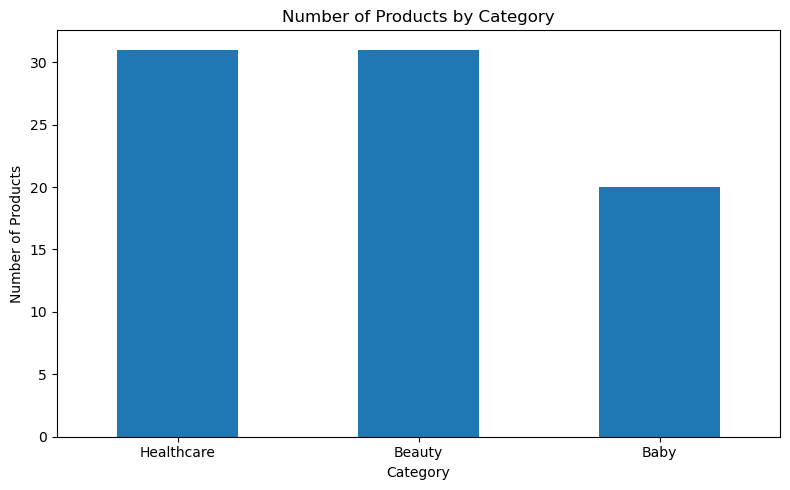

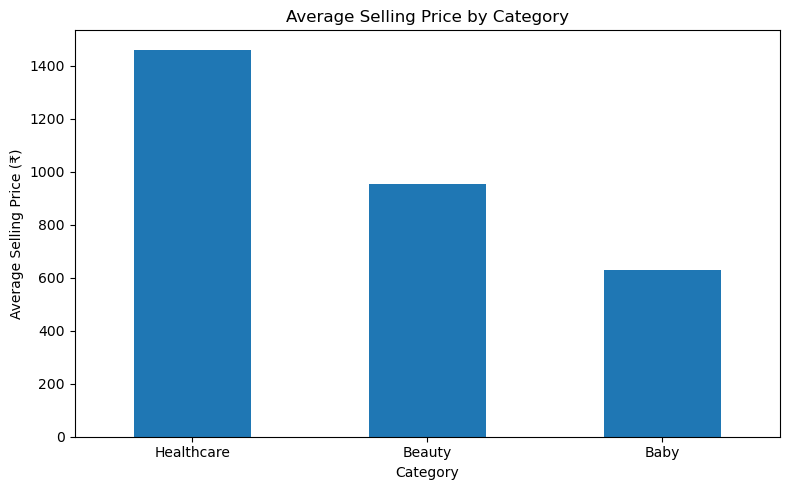

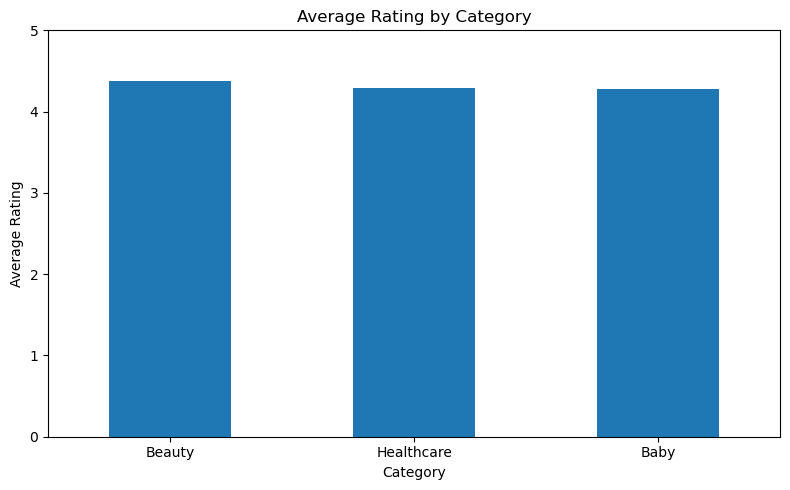

In [41]:
import matplotlib.pyplot as plt

# ============================================
# CHART 1: PRODUCTS BY CATEGORY
# ============================================

category_counts = master_df["Category"].value_counts()

plt.figure(figsize=(8, 5))
category_counts.plot(kind="bar")
plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================
# CHART 2: AVERAGE SELLING PRICE BY CATEGORY
# ============================================

avg_price = (
    master_df.groupby("Category")["Selling_Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_price.plot(kind="bar")
plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================
# CHART 3: AVERAGE RATING BY CATEGORY
# ============================================

avg_rating = (
    master_df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_rating.plot(kind="bar")
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

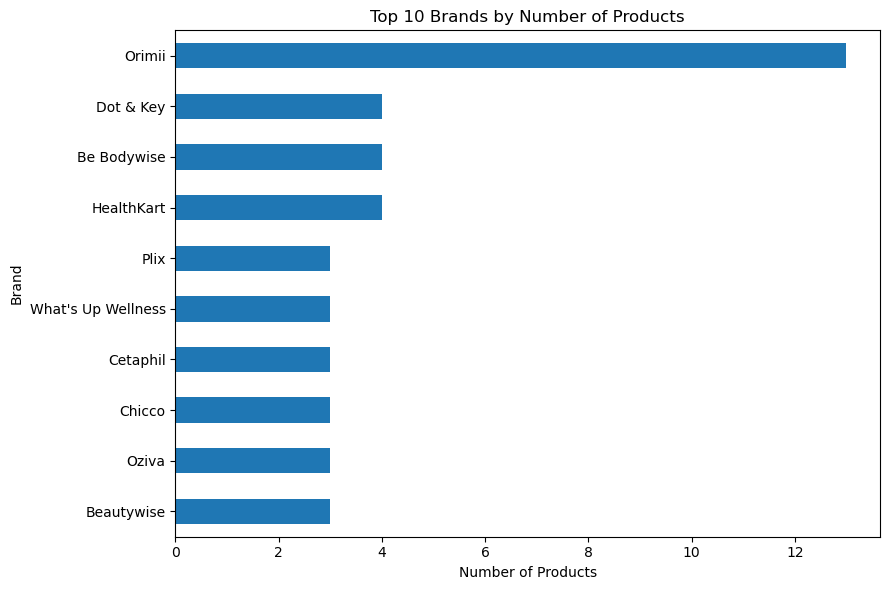

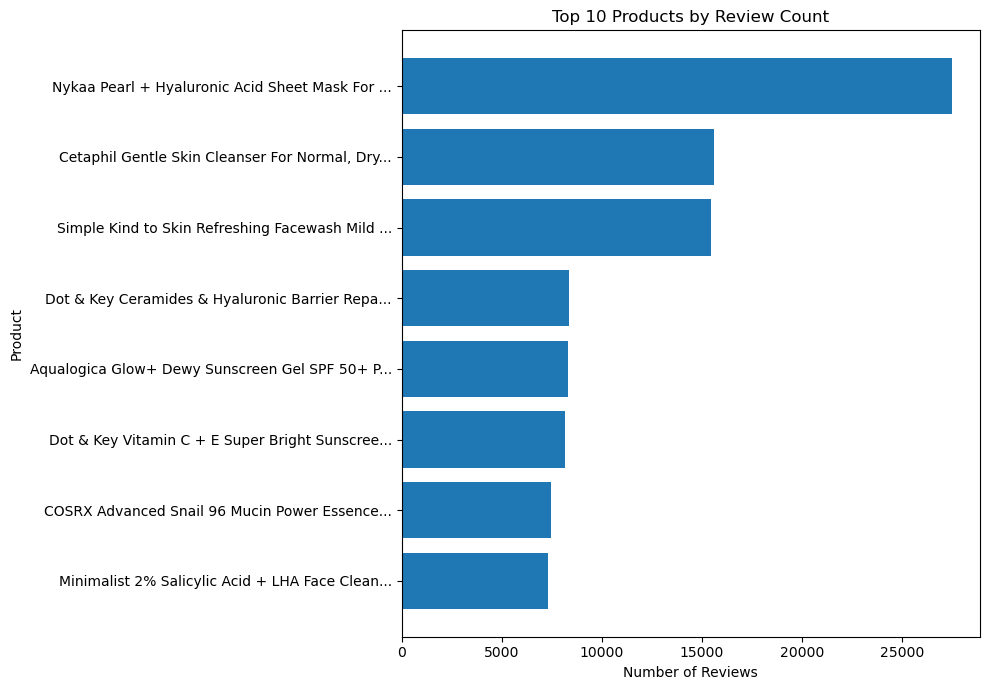

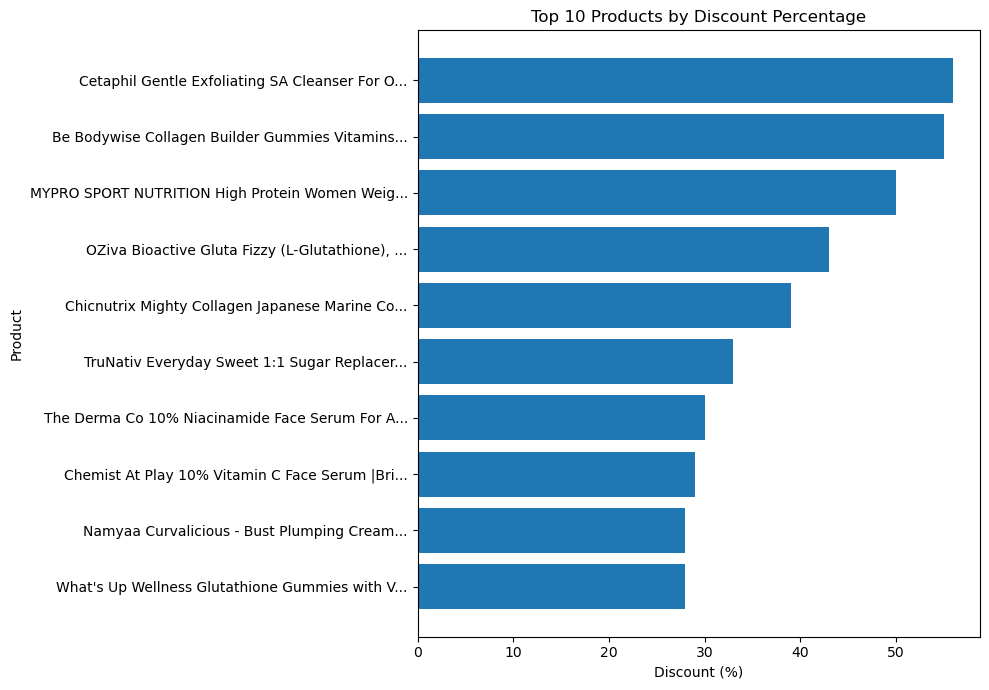

In [42]:
import matplotlib.pyplot as plt

# ==========================================
# CHART 4: TOP 10 BRANDS BY PRODUCT COUNT
# ==========================================

top_brands = (
    master_df["Brand"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))
top_brands.plot(kind="barh")
plt.title("Top 10 Brands by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


# ==========================================
# CHART 5: TOP 10 PRODUCTS BY REVIEW COUNT
# ==========================================

top_reviewed = (
    master_df.nlargest(10, "Review_Count")
    [["Product_Name", "Review_Count"]]
    .sort_values("Review_Count")
    .copy()
)

# Short names for better chart readability
top_reviewed["Short_Name"] = (
    top_reviewed["Product_Name"].str[:45] + "..."
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_reviewed["Short_Name"],
    top_reviewed["Review_Count"]
)
plt.title("Top 10 Products by Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


# ==========================================
# CHART 6: TOP 10 PRODUCTS BY DISCOUNT
# ==========================================

top_discount = (
    master_df.nlargest(10, "Discount_Percent")
    [["Product_Name", "Discount_Percent"]]
    .sort_values("Discount_Percent")
    .copy()
)

top_discount["Short_Name"] = (
    top_discount["Product_Name"].str[:45] + "..."
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_discount["Short_Name"],
    top_discount["Discount_Percent"]
)
plt.title("Top 10 Products by Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [43]:
# ==========================================
# STEP 32: CATEGORY-WISE DETAILED ANALYSIS
# ==========================================

category_analysis = (
    master_df.groupby("Category")
    .agg(
        Product_Count=("Product_Name", "count"),
        Average_MRP=("MRP", "mean"),
        Average_Selling_Price=("Selling_Price", "mean"),
        Average_Discount=("Discount_Percent", "mean"),
        Average_Rating=("Rating", "mean"),
        Total_Ratings=("Rating_Count", "sum"),
        Total_Reviews=("Review_Count", "sum")
    )
    .round(2)
)

print("========== CATEGORY-WISE ANALYSIS ==========")
display(category_analysis)

========== CATEGORY-WISE ANALYSIS ==========


,Product_Count,Average_MRP,Average_Selling_Price,Average_Discount,Average_Rating,Total_Ratings,Total_Reviews
Category,,,,,,,
Baby,20,695.15,630.75,8.85,4.28,3959.0,500.0
Beauty,31,1045.26,955.29,12.10,4.37,10313522.0,179021.0
Healthcare,31,1736.42,1460.74,17.90,4.29,77579.0,4736.0


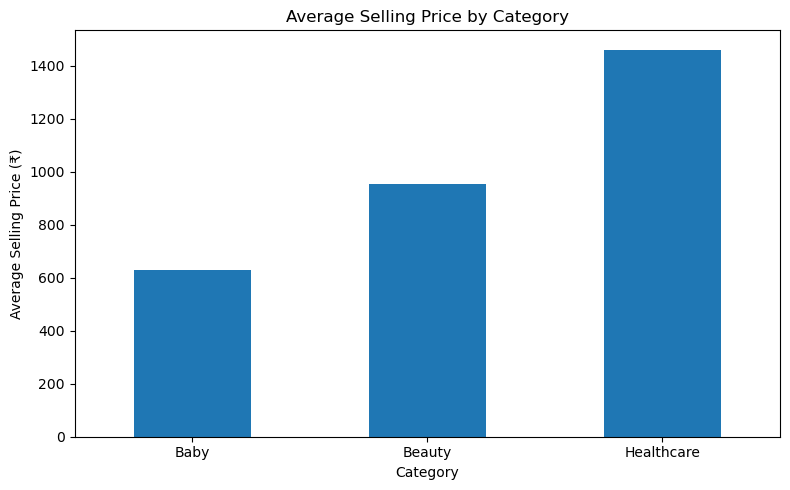

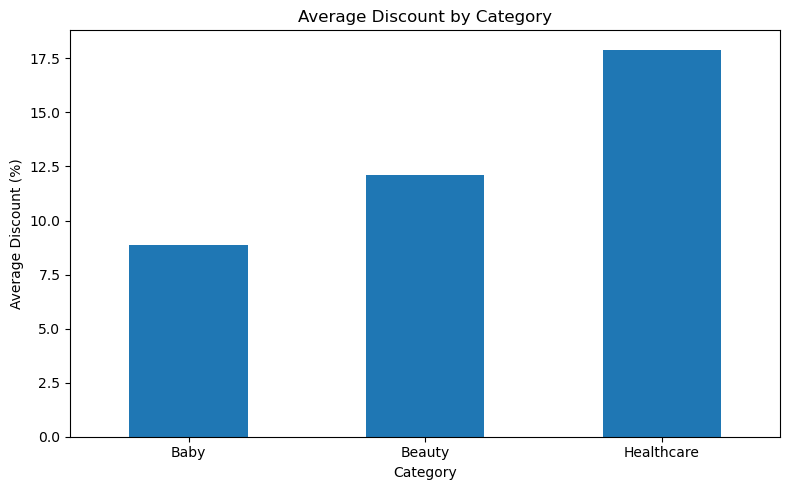

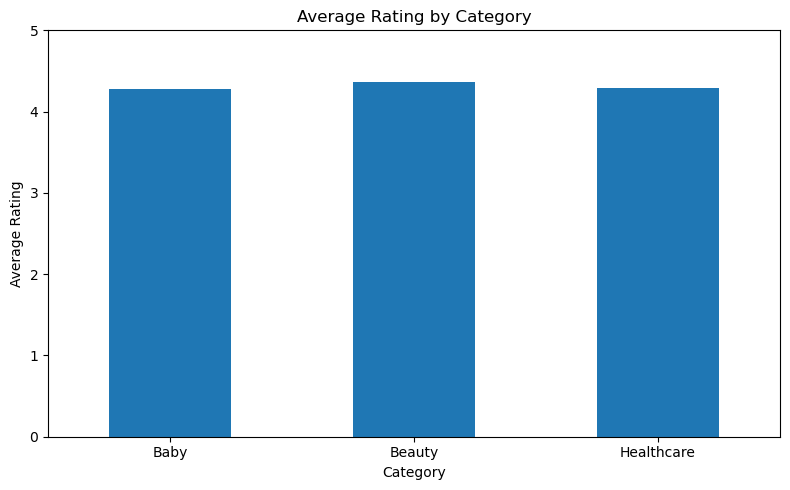

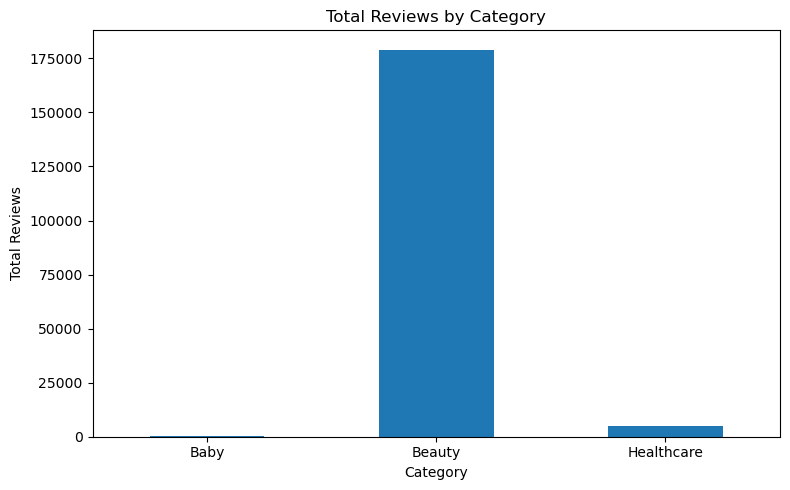

In [44]:
import matplotlib.pyplot as plt

# ==========================================
# CHART 7: AVERAGE SELLING PRICE
# ==========================================

plt.figure(figsize=(8, 5))

category_analysis["Average_Selling_Price"].plot(kind="bar")

plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ==========================================
# CHART 8: AVERAGE DISCOUNT
# ==========================================

plt.figure(figsize=(8, 5))

category_analysis["Average_Discount"].plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ==========================================
# CHART 9: AVERAGE RATING
# ==========================================

plt.figure(figsize=(8, 5))

category_analysis["Average_Rating"].plot(kind="bar")

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ==========================================
# CHART 10: TOTAL REVIEWS
# ==========================================

plt.figure(figsize=(8, 5))

category_analysis["Total_Reviews"].plot(kind="bar")

plt.title("Total Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Total Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
# ==========================================
# STEP 34: TOP PRODUCTS IN EACH CATEGORY
# ==========================================

for category in master_df["Category"].unique():

    print("\n" + "=" * 70)
    print(f"TOP 5 MOST REVIEWED PRODUCTS - {category.upper()}")
    print("=" * 70)

    top_products = (
        master_df[master_df["Category"] == category]
        .nlargest(5, "Review_Count")
        [["Product_Name",
          "Brand",
          "Selling_Price",
          "Discount_Percent",
          "Rating",
          "Rating_Count",
          "Review_Count"]]
        .reset_index(drop=True)
    )

    top_products.index = top_products.index + 1

    display(top_products)


TOP 5 MOST REVIEWED PRODUCTS - HEALTHCARE


,Product_Name,Brand,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,849.0,15.0,4.3,12264.0,529.0
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,549.0,0.0,4.3,12264.0,529.0
3,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,849.0,15.0,4.3,12264.0,529.0
4,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,2261.0,22.0,4.5,1672.0,334.0
5,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,1359.0,20.0,4.5,1672.0,334.0



TOP 5 MOST REVIEWED PRODUCTS - BEAUTY


,Product_Name,Brand,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count
1,Nykaa Pearl + Hyaluronic Acid Sheet Mask For G...,Nykaa Skin,80.0,20.0,4.5,7588498.0,27508.0
2,"Cetaphil Gentle Skin Cleanser For Normal, Dry ...",Cetaphil,418.0,9.0,4.5,431761.0,15611.0
3,"Cetaphil Gentle Skin Cleanser For Normal, Dry ...",Cetaphil,418.0,9.0,4.5,431761.0,15611.0
4,Simple Kind to Skin Refreshing Facewash Mild F...,Simple,594.0,15.0,4.5,223965.0,15467.0
5,Simple Kind to Skin Refreshing Facewash Mild F...,Simple,594.0,15.0,4.5,223965.0,15467.0



TOP 5 MOST REVIEWED PRODUCTS - BABY


,Product_Name,Brand,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count
1,Orimii Bump Hydrating Stretch Marks Cream and ...,Orimii,1251.0,10.0,4.3,1545.0,137.0
2,Orimii Bump Hydrating Body Butter for Reducing...,Orimii,660.0,5.0,4.4,421.0,71.0
3,Orimii Belly Treatment Elixir - Body Oil For S...,Orimii,660.0,5.0,4.3,348.0,61.0
4,Orimii Soap Free Gentle Cleansing Face Wash fo...,Orimii,470.0,5.0,4.3,106.0,26.0
5,Orimii No Salicylic Clarifying Face Serum For ...,Orimii,660.0,5.0,4.6,62.0,24.0


In [46]:
# ==========================================
# STEP 35: UNIQUE PRODUCT ANALYSIS
# ==========================================

# Keep one row for each Product + Brand combination
# We keep the row with the highest Review Count
unique_products = (
    master_df
    .sort_values("Review_Count", ascending=False)
    .drop_duplicates(subset=["Product_Name", "Brand"])
    .reset_index(drop=True)
)

print("Original master dataset :", len(master_df))
print("Unique products         :", len(unique_products))
print("Duplicate product rows  :", len(master_df) - len(unique_products))

print("\n========== TOP 5 UNIQUE PRODUCTS BY CATEGORY ==========")

for category in unique_products["Category"].unique():

    print("\n" + "=" * 70)
    print(f"TOP 5 UNIQUE MOST REVIEWED PRODUCTS - {category.upper()}")
    print("=" * 70)

    top_products = (
        unique_products[unique_products["Category"] == category]
        .nlargest(5, "Review_Count")
        [["Product_Name",
          "Brand",
          "Selling_Price",
          "Discount_Percent",
          "Rating",
          "Rating_Count",
          "Review_Count"]]
        .reset_index(drop=True)
    )

    top_products.index = top_products.index + 1

    display(top_products)

Original master dataset : 82
Unique products         : 71
Duplicate product rows  : 11

========== TOP 5 UNIQUE PRODUCTS BY CATEGORY ==========

TOP 5 UNIQUE MOST REVIEWED PRODUCTS - BEAUTY


,Product_Name,Brand,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count
1,Nykaa Pearl + Hyaluronic Acid Sheet Mask For G...,Nykaa Skin,80.0,20.0,4.5,7588498.0,27508.0
2,"Cetaphil Gentle Skin Cleanser For Normal, Dry ...",Cetaphil,418.0,9.0,4.5,431761.0,15611.0
3,Simple Kind to Skin Refreshing Facewash Mild F...,Simple,594.0,15.0,4.5,223965.0,15467.0
4,Dot & Key Ceramides & Hyaluronic Barrier Repai...,Dot & Key,336.0,15.0,4.4,138423.0,8383.0
5,Aqualogica Glow+ Dewy Sunscreen Gel SPF 50+ PA...,Aqualogica,429.0,14.0,4.4,200265.0,8322.0



TOP 5 UNIQUE MOST REVIEWED PRODUCTS - HEALTHCARE


,Product_Name,Brand,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count
1,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",Be Bodywise,849.0,15.0,4.3,12264.0,529.0
2,Beautywise Skin Brilliance Glutathione Dual Ac...,Beautywise,2261.0,22.0,4.5,1672.0,334.0
3,HealthKart HK Vitals Skin Radiance Collagen Su...,HealthKart,909.0,7.0,4.2,10121.0,332.0
4,MYPRO SPORT NUTRITION High Protein Women Weigh...,MYPRO SPORT NUTRITION,599.0,50.0,4.2,698.0,171.0
5,"OZiva Bioactive Gluta Fizzy (L-Glutathione), R...",Oziva,2375.0,43.0,4.2,2710.0,151.0



TOP 5 UNIQUE MOST REVIEWED PRODUCTS - BABY


,Product_Name,Brand,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count
1,Orimii Bump Hydrating Stretch Marks Cream and ...,Orimii,1251.0,10.0,4.3,1545.0,137.0
2,Orimii Bump Hydrating Body Butter for Reducing...,Orimii,660.0,5.0,4.4,421.0,71.0
3,Orimii Belly Treatment Elixir - Body Oil For S...,Orimii,660.0,5.0,4.3,348.0,61.0
4,Orimii Soap Free Gentle Cleansing Face Wash fo...,Orimii,470.0,5.0,4.3,106.0,26.0
5,Orimii No Salicylic Clarifying Face Serum For ...,Orimii,660.0,5.0,4.6,62.0,24.0


========== CORRELATION MATRIX ==========


,Selling_Price,Discount_Percent,Rating,Rating_Count,Review_Count
Selling_Price,1.00,-0.20,0.13,-0.09,-0.14
Discount_Percent,-0.20,1.00,-0.06,0.05,-0.04
Rating,0.13,-0.06,1.00,0.14,0.30
Rating_Count,-0.09,0.05,0.14,1.00,0.73
Review_Count,-0.14,-0.04,0.30,0.73,1.00


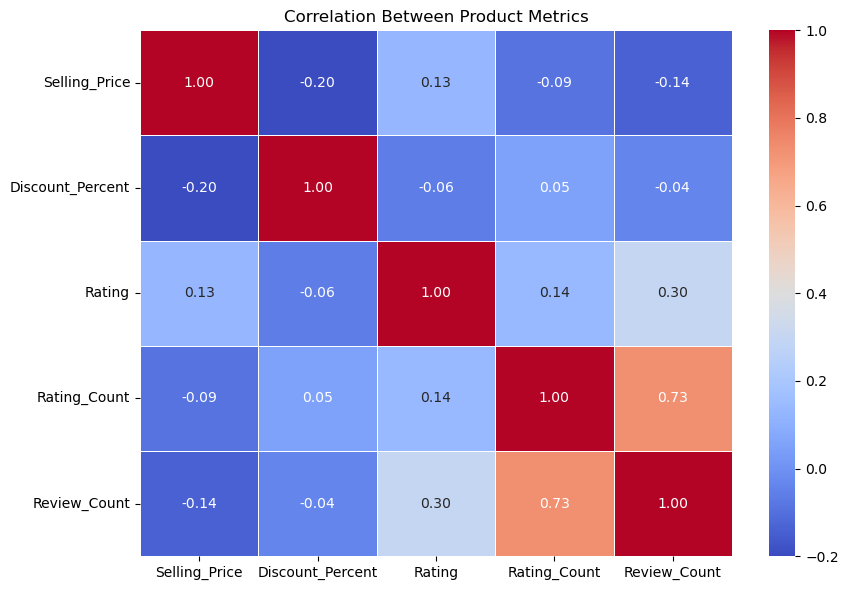

In [47]:
# ==========================================
# STEP 36: CORRELATION ANALYSIS
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
correlation_data = unique_products[
    [
        "Selling_Price",
        "Discount_Percent",
        "Rating",
        "Rating_Count",
        "Review_Count"
    ]
]

# Calculate correlation
correlation_matrix = correlation_data.corr().round(2)

print("========== CORRELATION MATRIX ==========")
display(correlation_matrix)


# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Product Metrics")
plt.tight_layout()
plt.show()

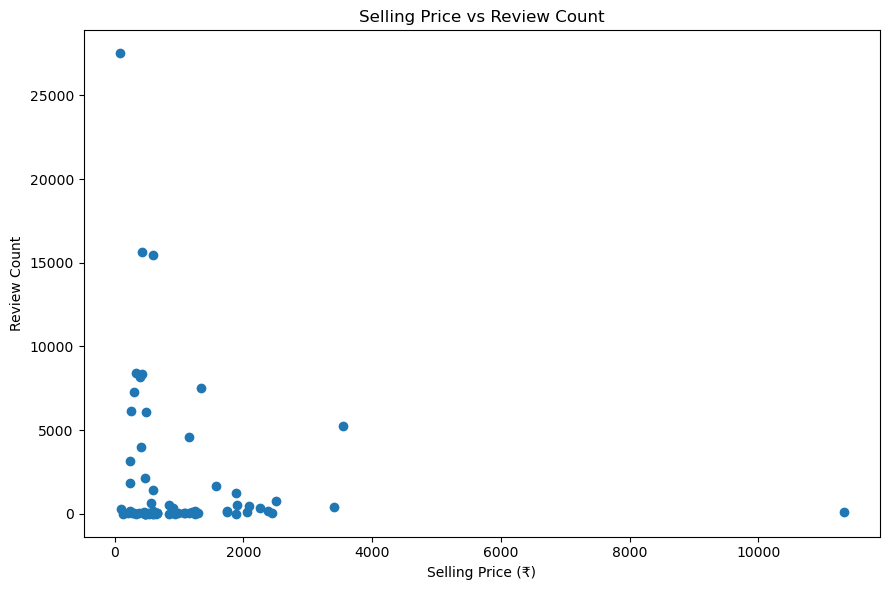

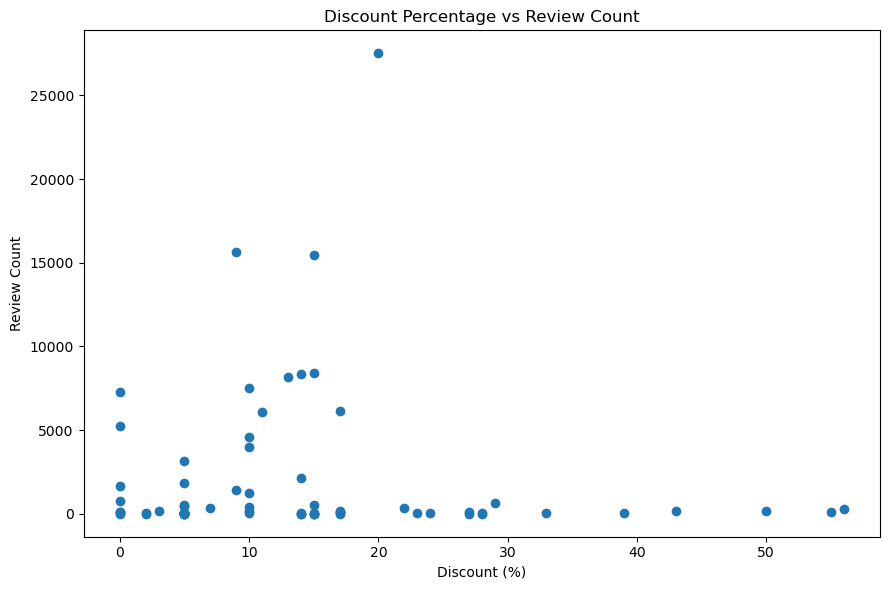

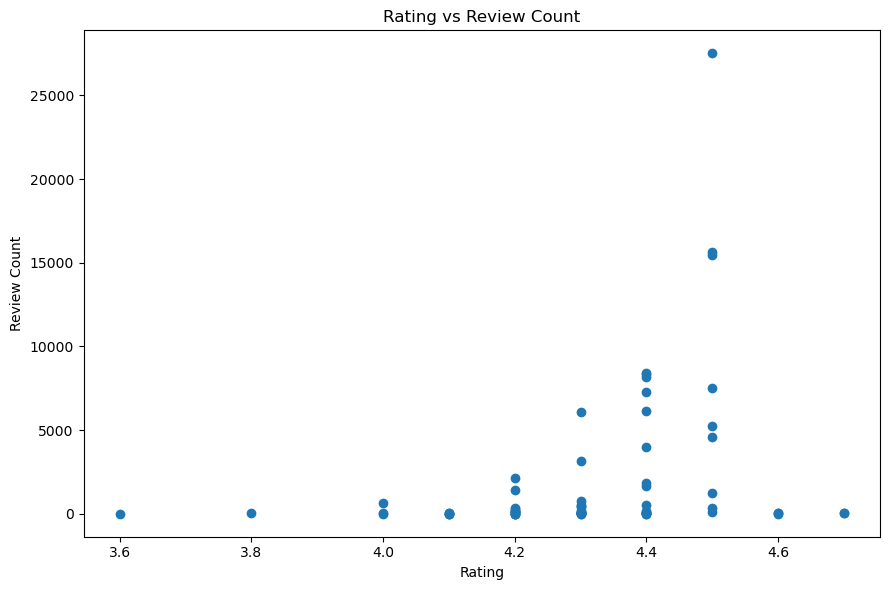

In [48]:
# ==========================================
# STEP 37: RELATIONSHIP ANALYSIS
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# CHART 11: SELLING PRICE vs REVIEW COUNT
# ==========================================

plt.figure(figsize=(9, 6))

plt.scatter(
    unique_products["Selling_Price"],
    unique_products["Review_Count"]
)

plt.title("Selling Price vs Review Count")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()


# ==========================================
# CHART 12: DISCOUNT vs REVIEW COUNT
# ==========================================

plt.figure(figsize=(9, 6))

plt.scatter(
    unique_products["Discount_Percent"],
    unique_products["Review_Count"]
)

plt.title("Discount Percentage vs Review Count")
plt.xlabel("Discount (%)")
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()


# ==========================================
# CHART 13: RATING vs REVIEW COUNT
# ==========================================

plt.figure(figsize=(9, 6))

plt.scatter(
    unique_products["Rating"],
    unique_products["Review_Count"]
)

plt.title("Rating vs Review Count")
plt.xlabel("Rating")
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()

In [49]:
# ==========================================
# STEP 38: DATA DICTIONARY
# ==========================================

import pandas as pd

data_dictionary = pd.DataFrame({
    "Column_Name": [
        "Product_Name",
        "Brand",
        "Category",
        "MRP",
        "Selling_Price",
        "Discount_Percent",
        "Rating",
        "Rating_Count",
        "Review_Count",
        "Pack_Size",
        "In_Stock",
        "Product_URL",
        "Scraped_Date",
        "Price_Range"
    ],

    "Description": [
        "Name of the product listed on Nykaa",
        "Brand associated with the product",
        "Main project category: Healthcare, Beauty, or Baby",
        "Maximum Retail Price of the product in ₹",
        "Current selling price of the product in ₹",
        "Percentage discount calculated from MRP and Selling Price",
        "Average customer rating of the product",
        "Number of customer ratings received by the product",
        "Number of written customer reviews",
        "Product pack size or quantity",
        "Indicates whether the product is currently in stock",
        "URL of the product page on Nykaa",
        "Date on which the product data was collected",
        "Selling price grouped into predefined price ranges"
    ],

    "Data_Type": [
        "Text",
        "Text",
        "Text",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Text",
        "Boolean",
        "Text/URL",
        "Date",
        "Categorical"
    ]
})

print("========== DATA DICTIONARY ==========")
display(data_dictionary)


# ==========================================
# DATA CLEANING DOCUMENTATION
# ==========================================

cleaning_documentation = pd.DataFrame({
    "Step": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8
    ],

    "Cleaning_Process": [
        "Removed duplicate product URLs",
        "Removed duplicate Product Name + Brand combinations for product-level analysis",
        "Converted MRP and Selling Price into numeric values",
        "Converted Rating, Rating Count and Review Count into numeric values",
        "Calculated Discount Percentage from MRP and Selling Price",
        "Converted stock information into True/False values",
        "Removed records missing essential product information",
        "Created Price Range categories for analysis"
    ],

    "Purpose": [
        "Avoid duplicate product records",
        "Prevent repeated product variants from affecting analysis",
        "Enable price calculations and statistical analysis",
        "Enable rating and customer engagement analysis",
        "Measure discount levels consistently",
        "Make stock information easier to analyze",
        "Improve dataset quality and reliability",
        "Enable price-range comparison"
    ]
})

print("\n========== DATA CLEANING DOCUMENTATION ==========")
display(cleaning_documentation)


# ==========================================
# SAVE DOCUMENTATION
# ==========================================

data_dictionary.to_csv(
    "nykaa_data_dictionary.csv",
    index=False
)

cleaning_documentation.to_csv(
    "nykaa_data_cleaning_documentation.csv",
    index=False
)

with pd.ExcelWriter("nykaa_project_documentation.xlsx") as writer:
    data_dictionary.to_excel(
        writer,
        sheet_name="Data Dictionary",
        index=False
    )

    cleaning_documentation.to_excel(
        writer,
        sheet_name="Cleaning Documentation",
        index=False
    )

print("\nDocumentation files saved successfully!")
print("1. nykaa_data_dictionary.csv")
print("2. nykaa_data_cleaning_documentation.csv")
print("3. nykaa_project_documentation.xlsx")

========== DATA DICTIONARY ==========


,Column_Name,Description,Data_Type
0,Product_Name,Name of the product listed on Nykaa,Text
1,Brand,Brand associated with the product,Text
2,Category,"Main project category: Healthcare, Beauty, or ...",Text
3,MRP,Maximum Retail Price of the product in ₹,Numeric
4,Selling_Price,Current selling price of the product in ₹,Numeric
5,Discount_Percent,Percentage discount calculated from MRP and Se...,Numeric
6,Rating,Average customer rating of the product,Numeric
7,Rating_Count,Number of customer ratings received by the pro...,Numeric
8,Review_Count,Number of written customer reviews,Numeric
9,Pack_Size,Product pack size or quantity,Text



========== DATA CLEANING DOCUMENTATION ==========


,Step,Cleaning_Process,Purpose
0,1,Removed duplicate product URLs,Avoid duplicate product records
1,2,Removed duplicate Product Name + Brand combina...,Prevent repeated product variants from affecti...
2,3,Converted MRP and Selling Price into numeric v...,Enable price calculations and statistical anal...
3,4,"Converted Rating, Rating Count and Review Coun...",Enable rating and customer engagement analysis
4,5,Calculated Discount Percentage from MRP and Se...,Measure discount levels consistently
5,6,Converted stock information into True/False va...,Make stock information easier to analyze
6,7,Removed records missing essential product info...,Improve dataset quality and reliability
7,8,Created Price Range categories for analysis,Enable price-range comparison



Documentation files saved successfully!
1. nykaa_data_dictionary.csv
2. nykaa_data_cleaning_documentation.csv
3. nykaa_project_documentation.xlsx


In [50]:
# ==========================================
# STEP 39: BUSINESS INSIGHTS
# ==========================================

print("=" * 70)
print("              NYKAA BUSINESS INSIGHTS")
print("=" * 70)


# ==========================================
# 1. CATEGORY WITH HIGHEST AVERAGE PRICE
# ==========================================

highest_price_category = (
    category_analysis["Average_Selling_Price"]
    .idxmax()
)

highest_price = (
    category_analysis["Average_Selling_Price"]
    .max()
)

print("\n1. HIGHEST AVERAGE SELLING PRICE")
print(
    f"{highest_price_category} has the highest average selling price "
    f"of ₹{highest_price:.2f}."
)


# ==========================================
# 2. CATEGORY WITH HIGHEST DISCOUNT
# ==========================================

highest_discount_category = (
    category_analysis["Average_Discount"]
    .idxmax()
)

highest_discount = (
    category_analysis["Average_Discount"]
    .max()
)

print("\n2. HIGHEST AVERAGE DISCOUNT")
print(
    f"{highest_discount_category} has the highest average discount "
    f"of {highest_discount:.2f}%."
)


# ==========================================
# 3. CATEGORY WITH HIGHEST RATING
# ==========================================

highest_rating_category = (
    category_analysis["Average_Rating"]
    .idxmax()
)

highest_rating = (
    category_analysis["Average_Rating"]
    .max()
)

print("\n3. HIGHEST AVERAGE RATING")
print(
    f"{highest_rating_category} has the highest average rating "
    f"of {highest_rating:.2f}/5."
)


# ==========================================
# 4. CATEGORY WITH MOST REVIEWS
# ==========================================

highest_reviews_category = (
    category_analysis["Total_Reviews"]
    .idxmax()
)

highest_reviews = (
    category_analysis["Total_Reviews"]
    .max()
)

print("\n4. HIGHEST CUSTOMER REVIEW ENGAGEMENT")
print(
    f"{highest_reviews_category} has the highest total review count "
    f"of {highest_reviews:,.0f}."
)


# ==========================================
# 5. TOP PRODUCTS BY CATEGORY
# ==========================================

print("\n" + "=" * 70)
print("TOP REVIEWED UNIQUE PRODUCT IN EACH CATEGORY")
print("=" * 70)

for category in unique_products["Category"].unique():

    top_product = (
        unique_products[
            unique_products["Category"] == category
        ]
        .nlargest(1, "Review_Count")
        .iloc[0]
    )

    print(f"\n{category}:")
    print("Product :", top_product["Product_Name"])
    print("Brand   :", top_product["Brand"])
    print("Reviews :", int(top_product["Review_Count"]))
    print("Rating  :", top_product["Rating"])
    print("Price   : ₹", top_product["Selling_Price"])


# ==========================================
# 6. HIGHEST DISCOUNTED PRODUCT
# ==========================================

highest_discount_product = (
    unique_products
    .nlargest(1, "Discount_Percent")
    .iloc[0]
)

print("\n" + "=" * 70)
print("HIGHEST DISCOUNTED PRODUCT")
print("=" * 70)

print("Product  :", highest_discount_product["Product_Name"])
print("Brand    :", highest_discount_product["Brand"])
print("Discount :", highest_discount_product["Discount_Percent"], "%")
print("MRP      : ₹", highest_discount_product["MRP"])
print("Price    : ₹", highest_discount_product["Selling_Price"])


# ==========================================
# 7. CATEGORY SUMMARY
# ==========================================

print("\n" + "=" * 70)
print("CATEGORY SUMMARY")
print("=" * 70)

display(
    category_analysis[
        [
            "Product_Count",
            "Average_Selling_Price",
            "Average_Discount",
            "Average_Rating",
            "Total_Reviews"
        ]
    ]
)

              NYKAA BUSINESS INSIGHTS

1. HIGHEST AVERAGE SELLING PRICE
Healthcare has the highest average selling price of ₹1460.74.

2. HIGHEST AVERAGE DISCOUNT
Healthcare has the highest average discount of 17.90%.

3. HIGHEST AVERAGE RATING
Beauty has the highest average rating of 4.37/5.

4. HIGHEST CUSTOMER REVIEW ENGAGEMENT
Beauty has the highest total review count of 179,021.

TOP REVIEWED UNIQUE PRODUCT IN EACH CATEGORY

Beauty:
Product : Nykaa Pearl + Hyaluronic Acid Sheet Mask For Glowing & Moisturised Skin - Formulated In Korea
Brand   : Nykaa Skin
Reviews : 27508
Rating  : 4.5
Price   : ₹ 80.0

Healthcare:
Product : Be Bodywise Biotin Hair Gummies - Zinc, Fibre, Multivitamin For Stronger Hair, Nails -No Added Sugar
Brand   : Be Bodywise
Reviews : 529
Rating  : 4.3
Price   : ₹ 849.0

Baby:
Product : Orimii Bump Hydrating Stretch Marks Cream and Oil For Women - Pregnancy Safe
Brand   : Orimii
Reviews : 137
Rating  : 4.3
Price   : ₹ 1251.0

HIGHEST DISCOUNTED PRODUCT
Product 

,Product_Count,Average_Selling_Price,Average_Discount,Average_Rating,Total_Reviews
Category,,,,,
Baby,20,630.75,8.85,4.28,500.0
Beauty,31,955.29,12.10,4.37,179021.0
Healthcare,31,1460.74,17.90,4.29,4736.0


In [51]:
# ==========================================
# STEP 40: BUSINESS INSIGHTS & RECOMMENDATIONS
# ==========================================

business_insights = pd.DataFrame({
    "Category": [
        "Healthcare",
        "Beauty",
        "Baby",
        "Healthcare",
        "Beauty",
        "Baby"
    ],

    "Insight": [
        "Healthcare has the highest average selling price.",
        "Beauty has the highest average rating and customer review engagement.",
        "Baby has the lowest average selling price and lowest average discount.",
        "Healthcare has the highest average discount.",
        "Beauty contains several highly reviewed products with strong customer engagement.",
        "Baby products show lower review volumes compared with Beauty and Healthcare."
    ],

    "Evidence": [
        "Average selling price = ₹1,460.74",
        "Average rating = 4.37/5; total reviews = 179,021",
        "Average selling price = ₹630.75; average discount = 8.85%",
        "Average discount = 17.90%",
        "Highest reviewed Beauty product has 27,508 reviews.",
        "Highest reviewed Baby product has 137 reviews."
    ],

    "Recommendation": [
        "Use value-based positioning, bundles and targeted promotions while maintaining premium pricing where justified.",
        "Leverage highly rated and highly reviewed products through social proof, recommendations and promotional campaigns.",
        "Focus on affordable bundles, introductory offers and stronger product visibility to encourage customer adoption.",
        "Evaluate discount effectiveness and margins to ensure higher discounts translate into stronger sales.",
        "Promote successful Beauty products as hero products and use their customer engagement to support cross-selling.",
        "Increase visibility, customer education and review-generation initiatives for suitable Baby products."
    ]
})

print("========== BUSINESS INSIGHTS & RECOMMENDATIONS ==========")
display(business_insights)


# ==========================================
# SAVE BUSINESS INSIGHTS
# ==========================================

business_insights.to_csv(
    "nykaa_business_insights_recommendations.csv",
    index=False
)

print("\nBusiness insights file saved successfully!")
print("nykaa_business_insights_recommendations.csv")

========== BUSINESS INSIGHTS & RECOMMENDATIONS ==========


,Category,Insight,Evidence,Recommendation
0,Healthcare,Healthcare has the highest average selling price.,"Average selling price = ₹1,460.74","Use value-based positioning, bundles and targe..."
1,Beauty,Beauty has the highest average rating and cust...,"Average rating = 4.37/5; total reviews = 179,021",Leverage highly rated and highly reviewed prod...
2,Baby,Baby has the lowest average selling price and ...,Average selling price = ₹630.75; average disco...,"Focus on affordable bundles, introductory offe..."
3,Healthcare,Healthcare has the highest average discount.,Average discount = 17.90%,Evaluate discount effectiveness and margins to...
4,Beauty,Beauty contains several highly reviewed produc...,"Highest reviewed Beauty product has 27,508 rev...",Promote successful Beauty products as hero pro...
5,Baby,Baby products show lower review volumes compar...,Highest reviewed Baby product has 137 reviews.,"Increase visibility, customer education and re..."



Business insights file saved successfully!
nykaa_business_insights_recommendations.csv


In [52]:
# ==========================================
# STEP 41: FINAL PROJECT EXCEL WORKBOOK
# ==========================================

final_excel_file = "Nykaa_Final_Project_Data.xlsx"

with pd.ExcelWriter(final_excel_file, engine="openpyxl") as writer:

    # 1. Master dataset
    master_df.to_excel(
        writer,
        sheet_name="Master Data",
        index=False
    )

    # 2. Unique products
    unique_products.to_excel(
        writer,
        sheet_name="Unique Products",
        index=False
    )

    # 3. Category analysis
    category_analysis.to_excel(
        writer,
        sheet_name="Category Analysis"
    )

    # 4. Business insights
    business_insights.to_excel(
        writer,
        sheet_name="Business Insights",
        index=False
    )

    # 5. Data dictionary
    data_dictionary.to_excel(
        writer,
        sheet_name="Data Dictionary",
        index=False
    )

    # 6. Cleaning documentation
    cleaning_documentation.to_excel(
        writer,
        sheet_name="Cleaning Documentation",
        index=False
    )

print("==========================================")
print("FINAL EXCEL FILE CREATED SUCCESSFULLY!")
print("==========================================")
print(f"File name: {final_excel_file}")

print("\nSheets included:")
print("1. Master Data")
print("2. Unique Products")
print("3. Category Analysis")
print("4. Business Insights")
print("5. Data Dictionary")
print("6. Cleaning Documentation")

FINAL EXCEL FILE CREATED SUCCESSFULLY!
File name: Nykaa_Final_Project_Data.xlsx

Sheets included:
1. Master Data
2. Unique Products
3. Category Analysis
4. Business Insights
5. Data Dictionary
6. Cleaning Documentation


In [53]:
import os

print(os.path.abspath("Nykaa_Final_Project_Data.xlsx"))

C:\Users\chait\Nykaa_Final_Project_Data.xlsx


In [54]:
import os
print(os.getcwd())

C:\Users\chait
